# Analyse du burnout étudiant par méthodes de data science

Ce projet s’inscrit dans le cadre du semestre 2 du Master 1 MIASHS.  
L’objectif est d’analyser les facteurs associés au burnout étudiant à partir de données académiques, comportementales et psychosociales.

Le projet poursuit deux objectifs complémentaires :

- un objectif prédictif : prédire le score de burnout et le niveau de risque associé ;
- un objectif explicatif : identifier les variables les plus liées au risque de burnout.

Le jeu de données utilisé est le *Student Mental Health and Burnout Dataset*, disponible sur Kaggle.  
Il contient environ 1 000 000 d’observations et 20 variables.  
Il s’agit d’un dataset synthétique, construit pour reproduire des relations statistiques réalistes entre pression académique, habitudes de vie et santé mentale.

Les résultats devront donc être interprétés avec prudence : ils permettent d’étudier des relations statistiques plausibles et de tester des méthodes de machine learning, mais ne constituent pas des conclusions cliniques ou diagnostiques.

## 1. Chargement des bibliothèques

Cette première étape consiste à importer les bibliothèques nécessaires pour l’analyse exploratoire, la visualisation, la modélisation, l’évaluation et la validation des modèles.

Une attention particulière sera portée à la validation des modèles, à l’évaluation sur des métriques adaptées et à l’explication des résultats.

In [3]:
# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Prétraitement
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Régression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Sélection de variables
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# Évaluation régression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Évaluation classification
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
    precision_score
)

# Options d'affichage
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [4]:
import os

os.listdir()

['.DS_Store',
 'Untitled.ipynb',
 'student_mental_health_burnout_1M.csv',
 '.ipynb_checkpoints']

## 2. Chargement et aperçu du jeu de données

Le dataset est chargé au format CSV.  
La première vérification porte sur ses dimensions, ses types de variables et la présence éventuelle de valeurs manquantes.

Cette étape permet de s’assurer que les données sont correctement importées avant de commencer l’analyse exploratoire.

In [5]:
df = pd.read_csv("student_mental_health_burnout_1M.csv")

df.head()

,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000


### Interprétation

L’aperçu des premières lignes confirme que le jeu de données a été correctement chargé.  
On retrouve les 20 variables annoncées dans la description du dataset, avec des informations démographiques, académiques, psychologiques, comportementales et sociales.

La variable `risk_level` correspond à une cible qualitative utilisée pour la classification, tandis que `burnout_score` et `dropout_risk` sont des variables quantitatives pouvant être mobilisées dans des tâches de régression.

On observe également que la majorité des variables sont numériques, à l’exception de `gender` et `risk_level`, qui devront être encodées avant la modélisation.

In [6]:
# Dimensions du dataset
print("Dimensions du dataset :", df.shape)

# Informations générales
df.info()

Dimensions du dataset : (1000000, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   age                   1000000 non-null  int64  
 1   gender                1000000 non-null  object 
 2   academic_year         1000000 non-null  int64  
 3   study_hours_per_day   1000000 non-null  float64
 4   exam_pressure         1000000 non-null  float64
 5   academic_performance  1000000 non-null  float64
 6   stress_level          1000000 non-null  float64
 7   anxiety_score         1000000 non-null  float64
 8   depression_score      1000000 non-null  float64
 9   sleep_hours           1000000 non-null  float64
 10  physical_activity     1000000 non-null  float64
 11  social_support        1000000 non-null  float64
 12  screen_time           1000000 non-null  float64
 13  internet_usage        1000000 non-null  float64
 1

In [7]:
# Statistiques descriptives des variables numériques
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000000.0,22.996456,3.742579,17.000000,20.000000,23.000000,26.000000,29.000000
academic_year,1000000.0,2.500782,1.117749,1.000000,2.000000,3.000000,4.000000,4.000000
study_hours_per_day,1000000.0,5.001727,1.989340,0.000000,3.650644,4.998222,6.345532,14.000000
exam_pressure,1000000.0,5.998810,1.548268,1.000000,4.944647,5.998906,7.051914,10.000000
academic_performance,1000000.0,70.999135,5.660073,42.365714,67.180912,70.999914,74.820937,97.246309
stress_level,1000000.0,4.246462,1.678998,0.000000,3.102593,4.244029,5.385464,10.000000
anxiety_score,1000000.0,2.986413,1.509844,0.000000,1.923747,2.969514,4.014996,10.000000
depression_score,1000000.0,1.274728,1.221273,0.000000,0.005198,1.047839,2.086397,8.530800
sleep_hours,1000000.0,6.501713,1.472972,3.000000,5.491047,6.501938,7.514642,10.000000
physical_activity,1000000.0,3.011153,1.463679,0.000000,1.990596,3.000619,4.011208,7.000000


In [8]:
# Vérification des valeurs manquantes
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values

age                     0
gender                  0
risk_level              0
mental_health_index     0
burnout_score           0
family_expectation      0
financial_stress        0
internet_usage          0
screen_time             0
social_support          0
physical_activity       0
sleep_hours             0
depression_score        0
anxiety_score           0
stress_level            0
academic_performance    0
exam_pressure           0
study_hours_per_day     0
academic_year           0
dropout_risk            0
dtype: int64

### Interprétation initiale du jeu de données

Le jeu de données contient **1 000 000 d’observations** et **20 variables**, ce qui constitue un volume important pour un projet de modélisation. Cette taille permet d’envisager des modèles robustes, tout en nécessitant une attention particulière aux temps de calcul lors des étapes de validation croisée ou d’optimisation des hyperparamètres.

Les variables sont principalement numériques : le dataset comporte **18 variables quantitatives** (`int64` ou `float64`) et **2 variables qualitatives** (`gender` et `risk_level`). Cette structure est adaptée à des tâches de régression, de classification supervisée et d’analyse exploratoire. La variable `risk_level` servira notamment de cible pour la classification, tandis que `burnout_score` et `dropout_risk` pourront être utilisées pour des tâches de régression.

Les statistiques descriptives montrent que les valeurs sont globalement cohérentes avec les bornes annoncées dans la documentation du dataset. Par exemple, l’âge varie de 17 à 29 ans, le score de burnout est compris entre 0 et 10, et l’indice de santé mentale varie également sur une échelle compatible avec son interprétation. Les variables liées au stress, au soutien social, au sommeil ou à la pression académique présentent des niveaux moyens réalistes pour une analyse comportementale.

On observe également que le `burnout_score` présente une moyenne relativement faible, autour de **1.78**, avec une médiane de **1.50**. Cela suggère qu’une grande partie des étudiants simulés se situe dans une zone de faible burnout, tandis qu’une minorité présente des niveaux plus élevés. Cette observation devra être mise en relation avec la variable `risk_level`, afin de vérifier l’existence d’un déséquilibre des classes.

Enfin, aucune valeur manquante n’est détectée dans le dataset. Cette absence de données manquantes simplifie la phase de préparation, car aucune imputation n’est nécessaire. Les étapes suivantes porteront donc principalement sur l’analyse exploratoire, l’encodage des variables qualitatives, la normalisation éventuelle des variables numériques et l’étude de la distribution des variables cibles.

Il faut toutefois rappeler que ce dataset est synthétique. Les résultats obtenus permettront donc d’évaluer des relations statistiques et des performances de modèles, mais ne devront pas être interprétés comme des conclusions cliniques sur de vrais étudiants.

## 2. Analyse de la variable cible : risk_level

La variable `risk_level` correspond au niveau de risque de burnout associé à chaque étudiant.  
Elle comporte trois modalités : `Low`, `Medium` et `High`.

Avant toute modélisation supervisée, il est nécessaire d’étudier sa distribution.  
Cette étape permet d’identifier un éventuel déséquilibre des classes, qui pourrait biaiser les modèles vers la classe majoritaire.

In [9]:
# Distribution brute des classes
df["risk_level"].value_counts()

risk_level
Low       766645
Medium    218275
High       15080
Name: count, dtype: int64

In [10]:
# Distribution en pourcentage
risk_distribution = df["risk_level"].value_counts(normalize=True) * 100
risk_distribution.round(2)

risk_level
Low       76.66
Medium    21.83
High       1.51
Name: proportion, dtype: float64

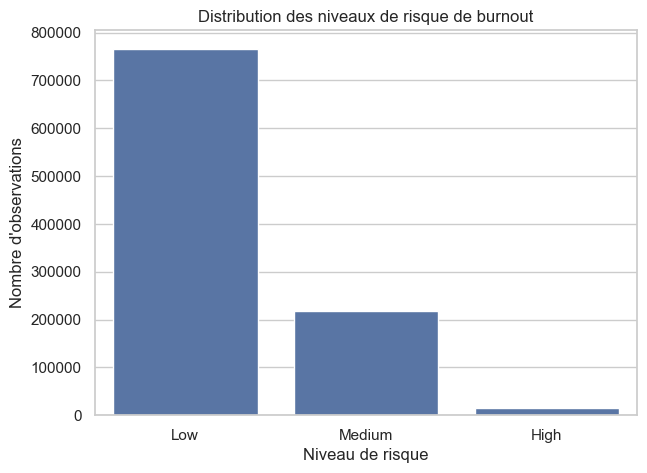

In [11]:
# Visualisation de la distribution des classes
plt.figure(figsize=(7, 5))
sns.countplot(
    data=df,
    x="risk_level",
    order=["Low", "Medium", "High"]
)
plt.title("Distribution des niveaux de risque de burnout")
plt.xlabel("Niveau de risque")
plt.ylabel("Nombre d'observations")
plt.show()

### Interprétation de la distribution de `risk_level`

La variable cible `risk_level` présente un déséquilibre marqué entre les trois classes.  
La classe `Low` est très majoritaire avec **766 645 observations**, soit **76,66 %** du dataset.  
La classe `Medium` représente **218 275 observations**, soit **21,83 %**, tandis que la classe `High` ne regroupe que **15 080 observations**, soit seulement **1,51 %** des données.

Ce déséquilibre est important à prendre en compte pour la suite de la classification supervisée.  
Un modèle évalué uniquement avec l’accuracy pourrait obtenir de bonnes performances apparentes en prédisant principalement la classe majoritaire `Low`, tout en détectant mal les étudiants les plus à risque (`High`).

Cependant, la classe `High` reste exploitable en valeur absolue, car elle contient plus de **15 000 observations**.  
Le problème n’est donc pas l’absence de données pour cette classe, mais sa sous-représentation relative par rapport aux autres niveaux de risque.

Pour cette raison, l’évaluation des modèles devra s’appuyer sur des métriques adaptées aux données déséquilibrées, notamment le **F1-score macro**, le **recall de la classe High** et la **matrice de confusion**.  
Des pistes d’amélioration comme la pondération des classes (`class_weight='balanced'`) ou le rééquilibrage pourront également être testées afin d’améliorer la détection des profils à risque élevé.

## 4. Typologie des variables

Le dataset contient des variables quantitatives et qualitatives.

Les variables quantitatives correspondent aux scores, durées ou indicateurs numériques. Elles décrivent par exemple l’âge, le temps d’étude, la pression académique, le niveau de stress, le sommeil, le score de burnout ou encore le risque de décrochage.

Les variables qualitatives correspondent aux modalités catégorielles, comme le genre ou le niveau de risque de burnout.

Cette distinction est importante, car les variables qualitatives devront être encodées avant la modélisation, tandis que certaines variables quantitatives pourront être normalisées selon les modèles utilisés.

In [12]:
# Séparation des variables numériques et catégorielles
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("Variables numériques :")
print(num_cols)

print("\nVariables catégorielles :")
print(cat_cols)

Variables numériques :
['age', 'academic_year', 'study_hours_per_day', 'exam_pressure', 'academic_performance', 'stress_level', 'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity', 'social_support', 'screen_time', 'internet_usage', 'financial_stress', 'family_expectation', 'burnout_score', 'mental_health_index', 'dropout_risk']

Variables catégorielles :
['gender', 'risk_level']


### Typologie des variables

Le dataset contient principalement des variables numériques.  
On compte **18 variables quantitatives**, qui décrivent des caractéristiques démographiques, académiques, psychologiques, comportementales et sociales : âge, temps d’étude, pression académique, stress, anxiété, sommeil, soutien social, score de burnout ou encore risque de décrochage.

Deux variables sont catégorielles : `gender` et `risk_level`.  
La variable `gender` sera utilisée comme variable explicative après encodage.  
La variable `risk_level` constitue la cible principale pour la classification supervisée, avec trois niveaux de risque : `Low`, `Medium` et `High`.

Cette typologie confirme que le jeu de données est majoritairement numérique, ce qui facilite l’application de modèles de régression, de classification et de clustering.  
Un encodage des variables catégorielles sera néanmoins nécessaire avant la modélisation.

## 5. Analyse des distributions des variables numériques

Cette étape vise à observer la répartition des principales variables quantitatives du dataset.  
L’objectif est d’identifier les tendances générales, les éventuelles asymétries et les variables susceptibles d’être liées au burnout étudiant.

Les variables analysées couvrent plusieurs dimensions : pression académique, santé mentale, sommeil, activité physique, soutien social et indicateurs de risque.

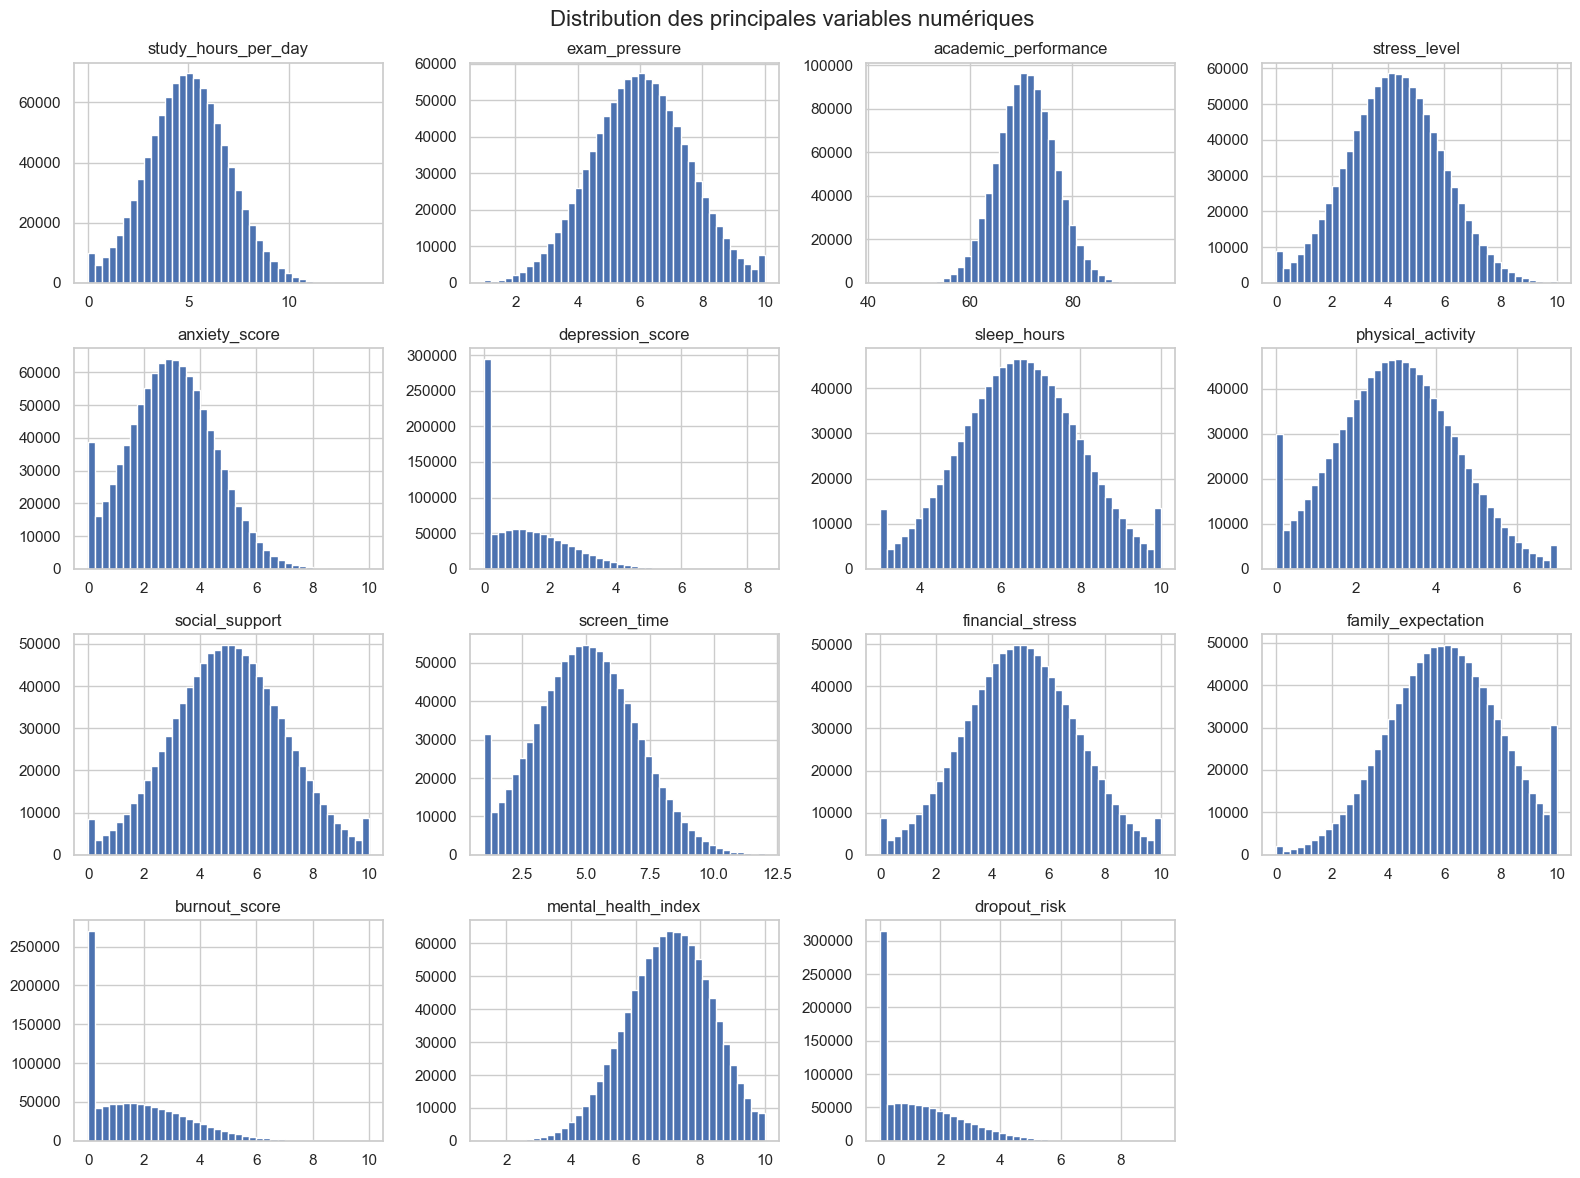

In [13]:
# Sélection des principales variables numériques à analyser
main_vars = [
    "study_hours_per_day",
    "exam_pressure",
    "academic_performance",
    "stress_level",
    "anxiety_score",
    "depression_score",
    "sleep_hours",
    "physical_activity",
    "social_support",
    "screen_time",
    "financial_stress",
    "family_expectation",
    "burnout_score",
    "mental_health_index",
    "dropout_risk"
]

# Visualisation des distributions
df[main_vars].hist(figsize=(16, 12), bins=40)
plt.suptitle("Distribution des principales variables numériques", fontsize=16)
plt.tight_layout()
plt.show()

### Interprétation des distributions numériques

Les distributions des variables numériques montrent une structure globalement cohérente avec la description du dataset. Plusieurs variables présentent une forme proche d’une distribution normale, notamment `study_hours_per_day`, `exam_pressure`, `academic_performance`, `stress_level`, `sleep_hours`, `social_support`, `screen_time`, `financial_stress` et `family_expectation`. Cela indique que les valeurs sont majoritairement concentrées autour d’un niveau moyen, avec peu d’observations aux extrêmes.

Certaines variables présentent toutefois une distribution plus asymétrique. C’est notamment le cas de `depression_score`, `burnout_score` et `dropout_risk`, qui sont fortement concentrées vers les valeurs faibles. Cette tendance suggère que la majorité des étudiants simulés présentent un niveau faible de dépression, de burnout ou de risque de décrochage, tandis qu’une minorité seulement atteint des niveaux élevés. Cette observation est cohérente avec le déséquilibre déjà observé dans la variable `risk_level`.

La variable `mental_health_index` présente au contraire une distribution plutôt concentrée vers des valeurs élevées, ce qui traduit un état de santé mentale globalement favorable pour une grande partie des étudiants du dataset. Cette distribution est logique puisque cet indicateur est inversement lié aux dimensions négatives comme le stress, l’anxiété, la dépression ou le burnout.

Ces premiers résultats montrent donc que le dataset présente des relations cohérentes : les indicateurs de risque sont concentrés sur des valeurs faibles, tandis que les indicateurs de bien-être sont globalement plus élevés. La suite de l’analyse devra vérifier plus précisément les relations entre ces variables, en particulier entre le sommeil, le stress, le soutien social, le score de burnout et le risque de décrochage.

## 6. Analyse des corrélations entre variables numériques

L’analyse des corrélations permet d’identifier les relations linéaires entre les variables numériques du dataset.  
Elle est particulièrement importante dans ce projet, car l’objectif n’est pas seulement de prédire le burnout, mais aussi de comprendre quels facteurs sont les plus associés au risque étudiant.

Une attention particulière est portée aux corrélations avec `burnout_score`, `mental_health_index` et `dropout_risk`.

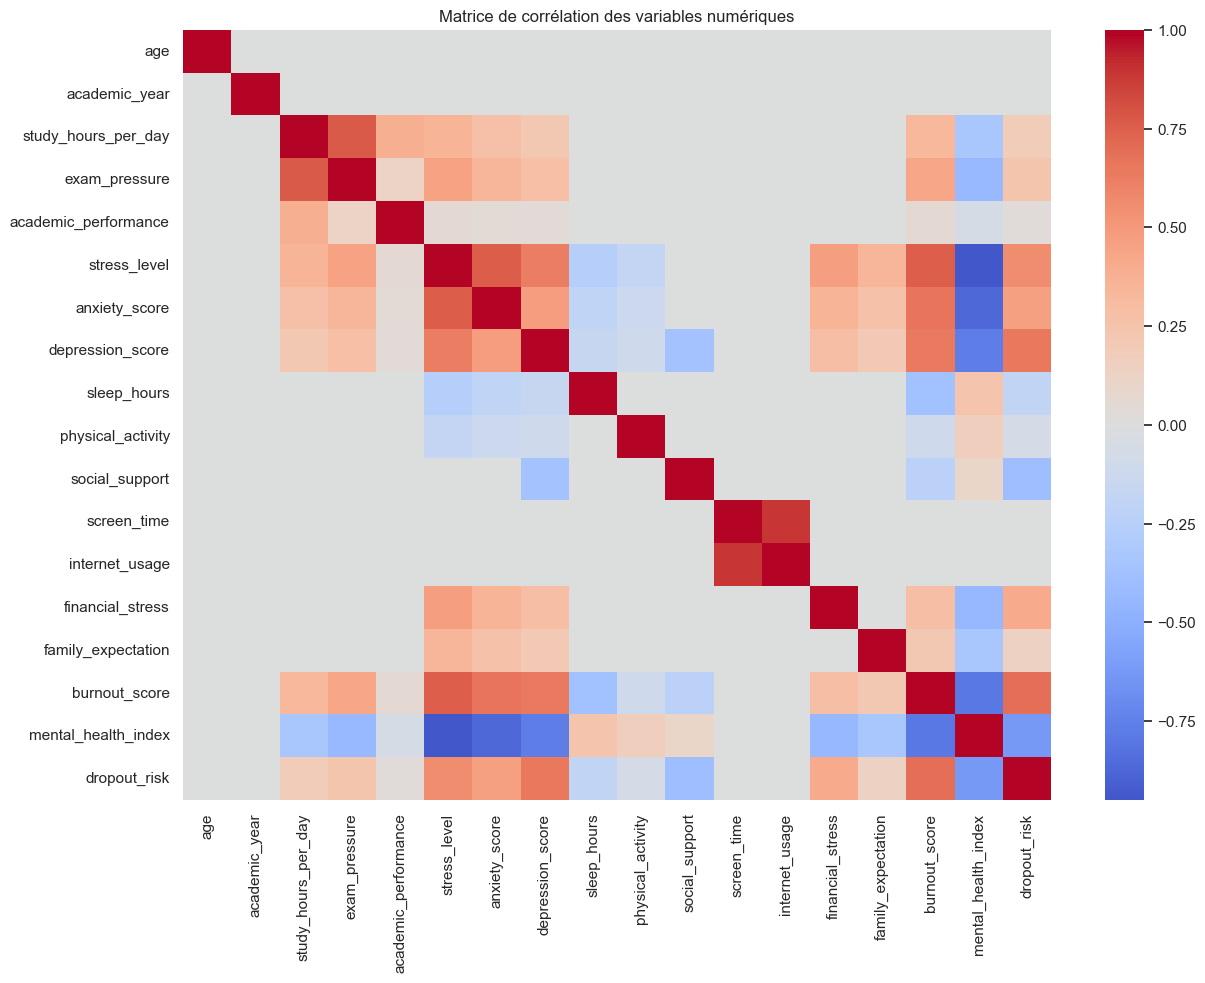

In [14]:
# Matrice de corrélation des variables numériques
corr_matrix = df[num_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Matrice de corrélation des variables numériques")
plt.show()

### Interprétation de la matrice de corrélation

La matrice de corrélation met en évidence plusieurs relations cohérentes avec la logique du dataset.

On observe d’abord que les indicateurs psychologiques négatifs, comme `stress_level`, `anxiety_score` et `depression_score`, sont positivement corrélés entre eux. Cela signifie que les étudiants présentant un niveau de stress élevé ont aussi tendance à présenter des niveaux plus élevés d’anxiété et de dépression. Cette relation est importante pour l’analyse explicative, car elle suggère une accumulation possible des facteurs de fragilité psychologique.

Le `burnout_score` est fortement associé aux variables de santé mentale négative, notamment le stress, l’anxiété et la dépression. Il est également positivement lié à la pression académique, au stress financier et aux attentes familiales. Ces résultats indiquent que le burnout ne dépend pas d’un seul facteur, mais d’une combinaison de pressions académiques, psychologiques et sociales.

À l’inverse, le `mental_health_index` présente des corrélations négatives avec le stress, l’anxiété, la dépression, le burnout et le risque de décrochage. Cette relation est logique, car un indice de santé mentale élevé correspond à une situation plus favorable. Le sommeil, l’activité physique et le soutien social semblent également associés positivement à cet indicateur, ce qui suggère un rôle protecteur de ces variables.

La variable `dropout_risk` est positivement corrélée au `burnout_score`, au stress, à l’anxiété et à la dépression. Cela montre que le risque de décrochage est lié aux difficultés psychologiques et au niveau de burnout. Cette relation renforce l’intérêt du projet, car elle permet de relier la santé mentale à des conséquences académiques potentielles.

Enfin, certaines variables comme `age` ou `academic_year` présentent peu de corrélations visibles avec les autres indicateurs. Elles semblent donc moins déterminantes dans l’explication directe du burnout, même si leur rôle pourra être vérifié lors de la modélisation.

Cette première analyse confirme que l’enjeu explicatif du projet est pertinent : les variables les plus associées au burnout semblent être le stress, l’anxiété, la dépression, la pression académique, le stress financier, les attentes familiales, le sommeil et le soutien social.

## 7. Variables les plus corrélées au score de burnout

Afin d’approfondir l’analyse explicative, les corrélations avec `burnout_score` sont étudiées plus précisément.  
Cette étape permet d’identifier les variables les plus associées au burnout étudiant avant la phase de modélisation.

In [15]:
# Corrélations avec burnout_score
corr_burnout = corr_matrix["burnout_score"].sort_values(ascending=False)

corr_burnout

burnout_score           1.000000
stress_level            0.753111
dropout_risk            0.689748
anxiety_score           0.668450
depression_score        0.642612
exam_pressure           0.434376
study_hours_per_day     0.335132
financial_stress        0.295702
family_expectation      0.217843
academic_performance    0.057089
academic_year           0.000555
age                    -0.001016
internet_usage         -0.001151
screen_time            -0.001215
physical_activity      -0.110074
social_support         -0.229811
sleep_hours            -0.371386
mental_health_index    -0.796527
Name: burnout_score, dtype: float64

### Interprétation des corrélations avec `burnout_score`

L’analyse des corrélations avec `burnout_score` permet d’identifier les variables les plus associées au niveau de burnout.

Les corrélations positives les plus fortes concernent d’abord les variables psychologiques : `stress_level` est fortement corrélé au burnout (\(r = 0.75\)), suivi de `anxiety_score` (\(r = 0.67\)) et `depression_score` (\(r = 0.64\)). Ces résultats indiquent que le burnout est étroitement lié à l’accumulation d’indicateurs de détresse psychologique.

Le `dropout_risk` présente également une forte corrélation positive avec le burnout (\(r = 0.69\)). Cela suggère qu’un niveau élevé de burnout est associé à une probabilité plus importante de risque de décrochage académique.

Les variables académiques jouent aussi un rôle, mais de manière moins forte. La pression des examens (`exam_pressure`) est modérément corrélée au burnout (\(r = 0.43\)), tandis que le temps d’étude (`study_hours_per_day`) présente une corrélation positive plus faible (\(r = 0.34\)). Cela montre que l’intensité du travail académique peut contribuer au burnout, mais que son effet semble moins direct que celui des facteurs psychologiques.

Les variables sociales et environnementales apparaissent également pertinentes. Le stress financier (`financial_stress`) est positivement corrélé au burnout (\(r = 0.30\)), tandis que les attentes familiales (`family_expectation`) présentent une corrélation plus modérée (\(r = 0.22\)).

À l’inverse, certaines variables semblent jouer un rôle protecteur. Le sommeil (`sleep_hours`) est négativement corrélé au burnout (\(r = -0.37\)), tout comme le soutien social (`social_support`, \(r = -0.23\)) et l’activité physique (`physical_activity`, \(r = -0.11\)). Ces résultats suggèrent qu’un meilleur équilibre de vie est associé à un niveau de burnout plus faible.

Enfin, `mental_health_index` présente la corrélation négative la plus forte avec le burnout (\(r = -0.80\)), ce qui est cohérent avec sa définition : plus l’indice de santé mentale est élevé, plus le score de burnout diminue.

Ces résultats confirment l’enjeu explicatif du projet : le burnout étudiant semble principalement lié aux facteurs psychologiques, mais aussi à la pression académique, au stress financier, au sommeil et au soutien social.

## 8. Visualisation des facteurs associés au burnout

Pour compléter l’analyse précédente, les corrélations avec `burnout_score` sont représentées graphiquement.  
Cette visualisation permet d’identifier plus facilement les facteurs associés positivement ou négativement au burnout.

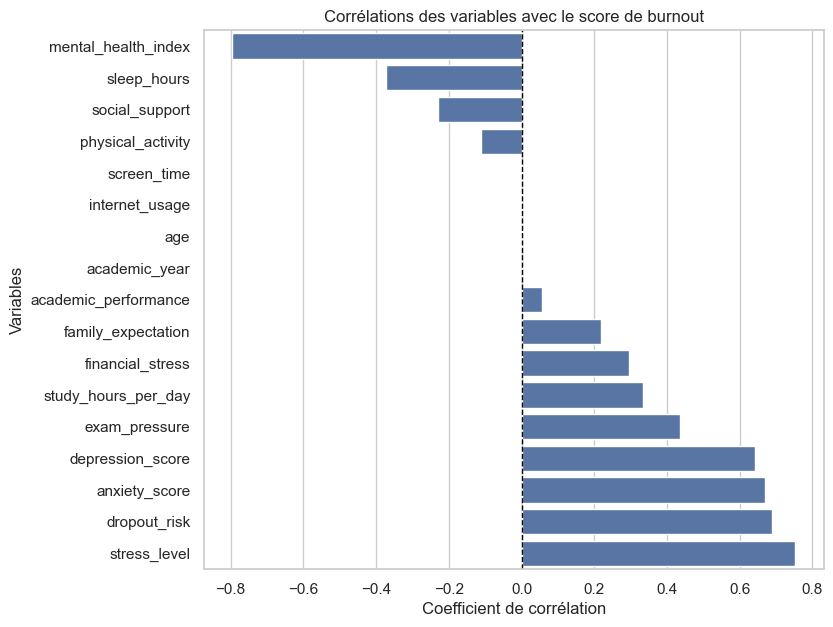

In [16]:
# Visualisation des corrélations avec burnout_score
corr_burnout_no_self = corr_burnout.drop("burnout_score").sort_values()

plt.figure(figsize=(8, 7))
sns.barplot(
    x=corr_burnout_no_self.values,
    y=corr_burnout_no_self.index
)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Corrélations des variables avec le score de burnout")
plt.xlabel("Coefficient de corrélation")
plt.ylabel("Variables")
plt.show()

### Interprétation du graphique des corrélations avec `burnout_score`

Ce graphique confirme visuellement les relations observées dans la matrice de corrélation.  
Les variables les plus positivement associées au burnout sont `stress_level`, `dropout_risk`, `anxiety_score` et `depression_score`. Cela montre que le score de burnout est fortement lié aux indicateurs de détresse psychologique et au risque de décrochage.

La pression académique (`exam_pressure`) et le temps d’étude (`study_hours_per_day`) présentent également une corrélation positive avec le burnout, mais d’intensité plus modérée. Cela suggère que la charge académique participe au risque de burnout, sans en être l’unique explication.

À l’inverse, `mental_health_index`, `sleep_hours`, `social_support` et `physical_activity` sont négativement corrélés au burnout. Ces variables peuvent être interprétées comme des facteurs protecteurs : un meilleur état de santé mentale, un sommeil plus important, un soutien social plus élevé et une activité physique régulière sont associés à un score de burnout plus faible.

Enfin, certaines variables comme `age`, `academic_year`, `screen_time` ou `internet_usage` présentent une corrélation proche de zéro. Elles semblent donc peu liées directement au score de burnout dans ce dataset.

Cette analyse permet de dégager une première conclusion explicative : le burnout étudiant semble surtout dépendre de la détresse psychologique, de la pression académique et de certains facteurs de protection liés au mode de vie.

## 9. Relations entre le score de burnout et les variables clés

Après l’analyse des corrélations, il est utile de visualiser plus directement les relations entre `burnout_score` et les variables les plus associées au burnout.

Cette étape permet de vérifier si les relations observées sont globalement linéaires, monotones ou plus dispersées.

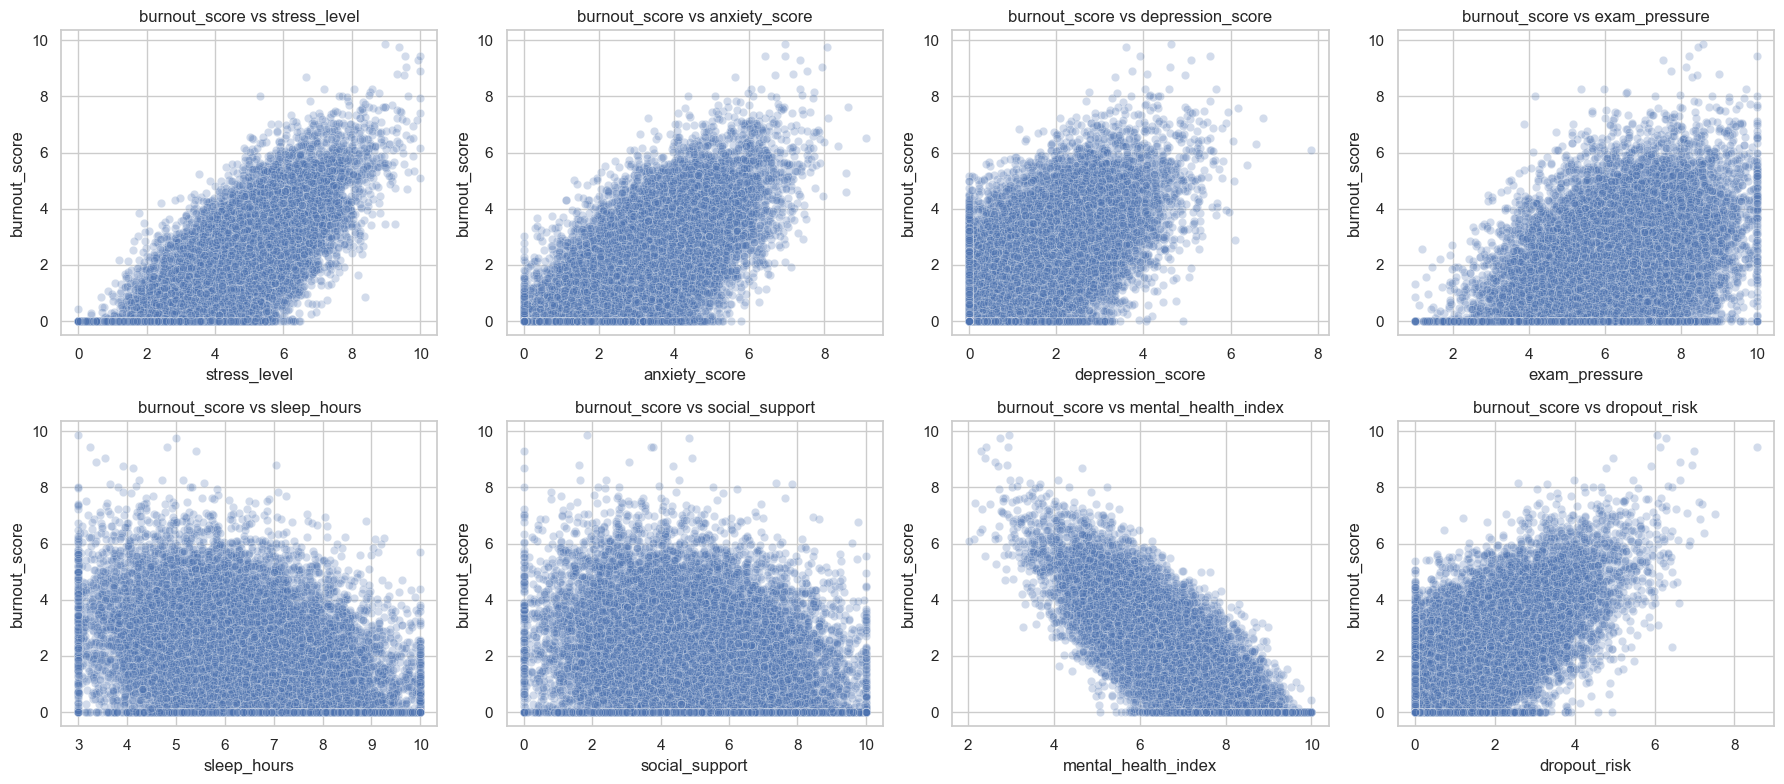

In [17]:
key_vars = [
    "stress_level",
    "anxiety_score",
    "depression_score",
    "exam_pressure",
    "sleep_hours",
    "social_support",
    "mental_health_index",
    "dropout_risk"
]

# Échantillonnage pour alléger l'affichage
df_sample = df.sample(n=20000, random_state=42)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(key_vars):
    sns.scatterplot(
        data=df_sample,
        x=col,
        y="burnout_score",
        alpha=0.25,
        ax=axes[i]
    )
    axes[i].set_title(f"burnout_score vs {col}")

plt.tight_layout()
plt.show()

### Interprétation des relations avec `burnout_score`

Les nuages de points confirment les tendances observées dans l’analyse des corrélations.

Les variables `stress_level`, `anxiety_score` et `depression_score` présentent une relation positive nette avec `burnout_score`. Plus ces indicateurs de détresse psychologique augmentent, plus le score de burnout tend à augmenter. La relation est particulièrement marquée pour `stress_level`, ce qui confirme son rôle central dans l’explication du burnout.

La variable `exam_pressure` montre également une relation positive avec le burnout, mais plus dispersée. Cela suggère que la pression liée aux examens contribue au burnout, sans suffire à elle seule à l’expliquer. Son effet semble s’ajouter à d’autres facteurs psychologiques ou sociaux.

À l’inverse, `sleep_hours`, `social_support` et surtout `mental_health_index` sont associés négativement au burnout. Le graphique entre `mental_health_index` et `burnout_score` montre une relation décroissante très nette : plus l’indice de santé mentale est élevé, plus le score de burnout diminue. Le sommeil et le soutien social apparaissent aussi comme des facteurs potentiellement protecteurs, même si leur relation avec le burnout est plus dispersée.

Enfin, `dropout_risk` augmente globalement avec `burnout_score`, ce qui confirme le lien entre burnout et risque de décrochage. Cette relation renforce l’intérêt du projet, car elle montre que le burnout peut être associé à des conséquences académiques importantes.

Ces visualisations confirment que le burnout étudiant est principalement lié à une combinaison de facteurs psychologiques, académiques et sociaux. Elles justifient l’utilisation de modèles prédictifs, mais aussi une analyse explicative détaillée des variables les plus importantes.

## 10. Comparaison des variables selon le niveau de risque

Après avoir analysé les relations avec le score de burnout, il est nécessaire d’observer comment les principales variables varient selon les catégories de risque `Low`, `Medium` et `High`.

Cette étape permet de mieux comprendre les différences entre les profils d’étudiants et de préparer la phase de classification supervisée.

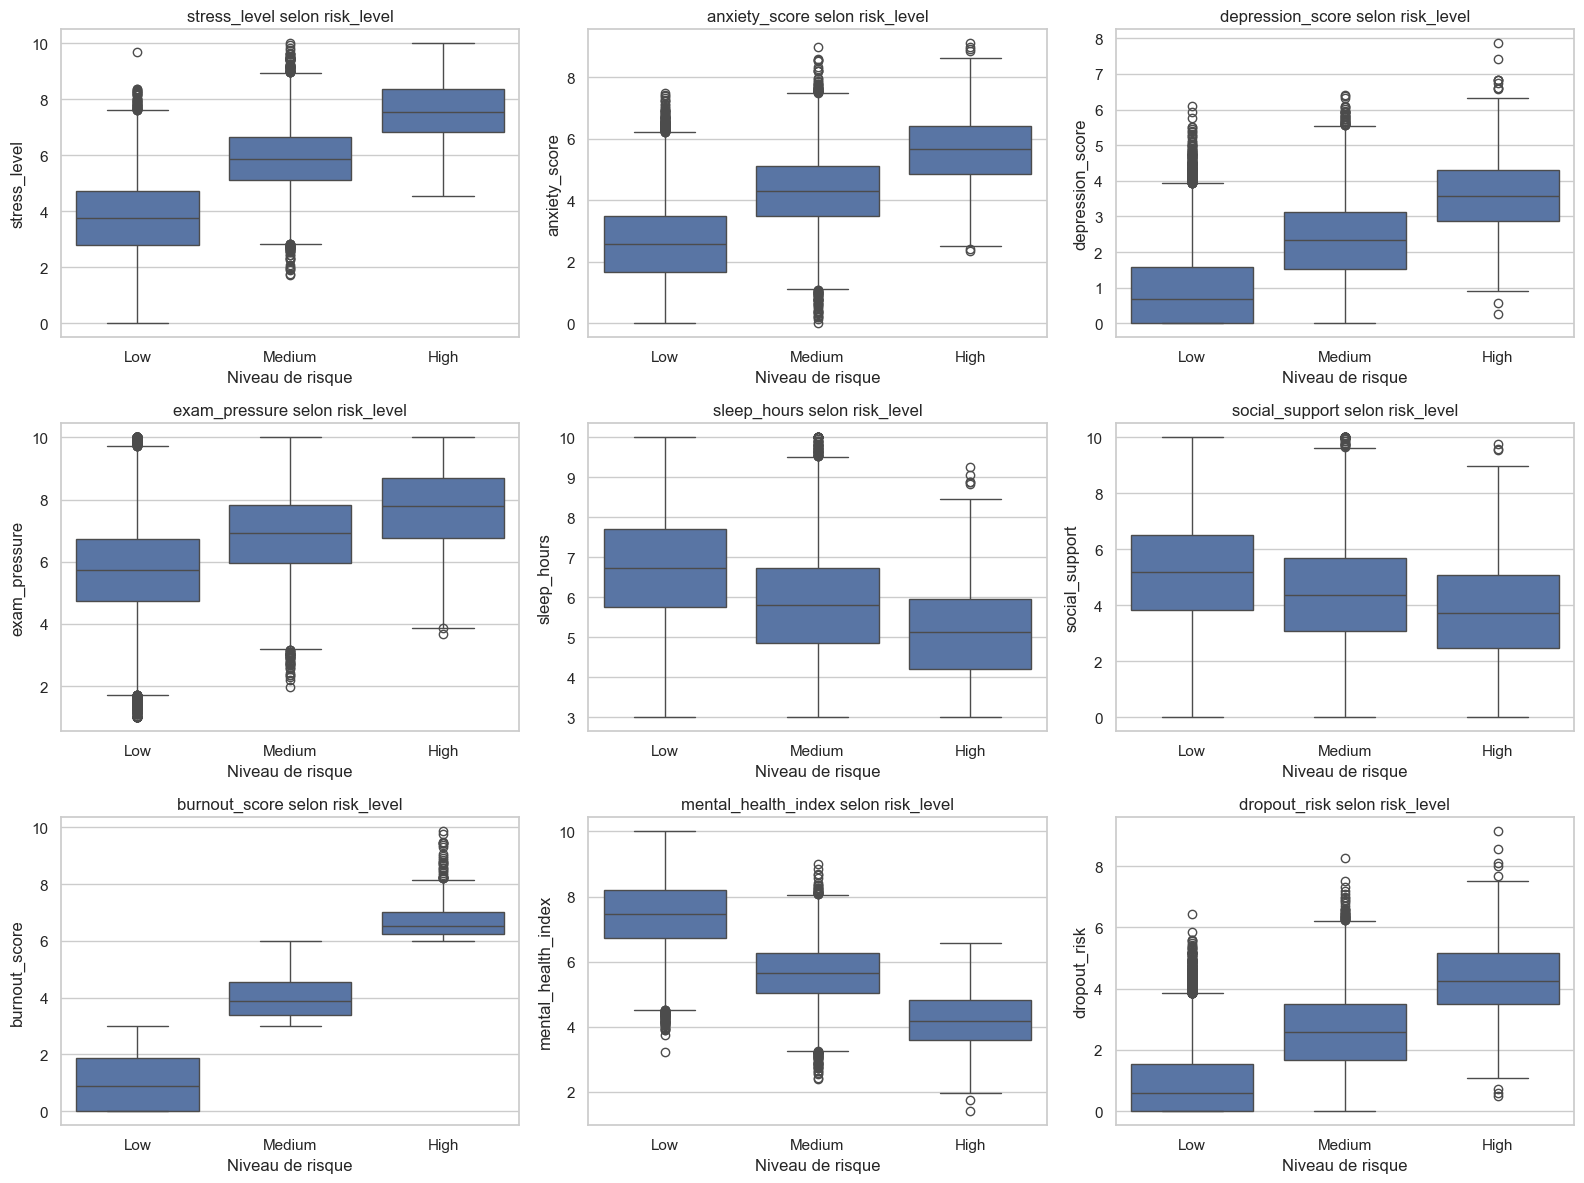

In [18]:
# Variables clés à comparer selon risk_level
compare_vars = [
    "stress_level",
    "anxiety_score",
    "depression_score",
    "exam_pressure",
    "sleep_hours",
    "social_support",
    "burnout_score",
    "mental_health_index",
    "dropout_risk"
]

# Échantillonnage pour rendre les graphiques lisibles
df_sample_box = df.sample(n=50000, random_state=42)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(compare_vars):
    sns.boxplot(
        data=df_sample_box,
        x="risk_level",
        y=col,
        order=["Low", "Medium", "High"],
        ax=axes[i]
    )
    axes[i].set_title(f"{col} selon risk_level")
    axes[i].set_xlabel("Niveau de risque")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

### Interprétation des variables selon `risk_level`

Les boxplots montrent des différences nettes entre les trois niveaux de risque de burnout (`Low`, `Medium`, `High`).  
Ces différences confirment que la variable `risk_level` est cohérente avec les principaux indicateurs psychologiques, académiques et comportementaux du dataset.

Les variables `stress_level`, `anxiety_score` et `depression_score` augmentent clairement avec le niveau de risque.  
Les étudiants classés en risque `High` présentent des niveaux médians de stress, d’anxiété et de dépression plus élevés que les étudiants des classes `Low` et `Medium`.  
Cela confirme que la détresse psychologique constitue un facteur central dans l’identification des profils à risque.

La pression académique (`exam_pressure`) suit également une progression croissante entre les classes.  
Les étudiants du groupe `High` déclarent une pression d’examen plus forte, ce qui suggère que les contraintes académiques contribuent au risque de burnout.

À l’inverse, `sleep_hours`, `social_support` et `mental_health_index` diminuent lorsque le niveau de risque augmente.  
Les étudiants classés en risque `High` dorment moins, disposent d’un soutien social plus faible et présentent un indice de santé mentale plus bas.  
Ces variables peuvent donc être interprétées comme des facteurs protecteurs lorsqu’elles sont élevées.

Le `burnout_score` distingue très clairement les trois classes.  
La médiane augmente fortement de `Low` à `Medium`, puis de `Medium` à `High`, ce qui confirme la cohérence entre la variable continue `burnout_score` et la variable catégorielle `risk_level`.

Enfin, `dropout_risk` augmente avec le niveau de risque de burnout.  
Cela montre que les étudiants les plus exposés au burnout sont également ceux qui présentent le risque de décrochage le plus élevé.

Dans l’ensemble, ces résultats renforcent l’enjeu explicatif du projet : le risque de burnout apparaît lié à une combinaison de détresse psychologique, de pression académique, de manque de sommeil, de faible soutien social et de risque de décrochage.

## 11. Feature engineering

Afin d’améliorer l’interprétation et potentiellement la performance des modèles, plusieurs variables synthétiques sont créées à partir des variables existantes.

Ces nouvelles variables visent à résumer des dimensions importantes du risque de burnout :

- un déficit de sommeil ;
- un indice de pression académique ;
- un indice de détresse psychologique ;
- un indicateur de protection sociale ;
- un indicateur d’équilibre de vie.

L’objectif est de tester si ces variables construites améliorent les performances des modèles par rapport à l’utilisation des variables initiales seules.

In [19]:
# Copie du dataset pour conserver les données brutes
df_fe = df.copy()

# Déficit de sommeil par rapport à une référence de 8 heures
df_fe["sleep_deficit"] = (8 - df_fe["sleep_hours"]).clip(lower=0)

# Indice de pression académique
df_fe["academic_pressure_index"] = (
    df_fe["study_hours_per_day"] + df_fe["exam_pressure"] + df_fe["family_expectation"]
) / 3

# Indice de détresse psychologique
df_fe["psychological_distress_index"] = (
    df_fe["stress_level"] + df_fe["anxiety_score"] + df_fe["depression_score"]
) / 3

# Indice de protection sociale
df_fe["support_protection_index"] = (
    df_fe["social_support"] + df_fe["sleep_hours"] + df_fe["physical_activity"]
) / 3

# Indice de risque comportemental
df_fe["behavioral_risk_index"] = (
    df_fe["screen_time"] + df_fe["internet_usage"] + df_fe["sleep_deficit"]
) / 3

# Vérification des nouvelles variables
df_fe[
    [
        "sleep_deficit",
        "academic_pressure_index",
        "psychological_distress_index",
        "support_protection_index",
        "behavioral_risk_index"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
sleep_deficit,1000000.0,1.618198,1.284917,0.000000,0.485358,1.498062,2.508953,5.000000
academic_pressure_index,1000000.0,5.661275,1.288062,0.424226,4.785969,5.663018,6.535877,11.067395
psychological_distress_index,1000000.0,2.835868,1.280558,0.000000,1.911172,2.777214,3.695668,8.544727
support_protection_index,1000000.0,4.837530,0.956160,1.000000,4.185135,4.835792,5.488231,8.812669
behavioral_risk_index,1000000.0,3.891694,1.402341,0.666667,2.900839,3.871577,4.843788,9.871540


### Interprétation des variables créées

La phase de feature engineering a permis de construire cinq nouvelles variables synthétiques à partir des variables initiales.  
Ces indicateurs visent à résumer des dimensions importantes du risque de burnout et à améliorer l’interprétation des futurs modèles.

La variable `sleep_deficit` mesure l’écart entre la durée de sommeil observée et une référence de 8 heures. Sa moyenne est d’environ **1.62 heure**, ce qui indique qu’une partie importante des étudiants présente un déficit de sommeil modéré.

L’indice `academic_pressure_index` combine le temps d’étude, la pression des examens et les attentes familiales. Sa moyenne est d’environ **5.66**, ce qui traduit un niveau de pression académique globalement intermédiaire dans le dataset.

L’indice `psychological_distress_index`, construit à partir du stress, de l’anxiété et de la dépression, présente une moyenne de **2.84**. Il permet de résumer les dimensions psychologiques négatives dans une seule variable, ce qui sera utile pour l’analyse explicative.

L’indice `support_protection_index` combine le soutien social, le sommeil et l’activité physique. Sa moyenne est d’environ **4.84**. Cette variable représente une forme de protection liée au mode de vie et à l’environnement social.

Enfin, `behavioral_risk_index` synthétise le temps d’écran, l’usage d’internet et le déficit de sommeil. Sa moyenne est de **3.89**, indiquant un niveau de risque comportemental modéré.

Ces nouvelles variables seront comparées aux variables initiales dans la phase de modélisation afin de vérifier si elles améliorent la performance prédictive ou l’interprétation des modèles.

## 12. Corrélations des nouvelles variables avec le score de burnout

Après la création des variables synthétiques, il est nécessaire de vérifier leur lien avec `burnout_score`.  
Cette étape permet de déterminer si le feature engineering apporte une information pertinente pour la suite de la modélisation.

In [20]:
new_features = [
    "sleep_deficit",
    "academic_pressure_index",
    "psychological_distress_index",
    "support_protection_index",
    "behavioral_risk_index"
]

corr_new_features = df_fe[new_features + ["burnout_score"]].corr()["burnout_score"].sort_values(ascending=False)
corr_new_features

burnout_score                   1.000000
psychological_distress_index    0.796146
academic_pressure_index         0.457122
sleep_deficit                   0.369751
behavioral_risk_index           0.111774
support_protection_index       -0.405226
Name: burnout_score, dtype: float64

### Interprétation des corrélations des variables créées

Les corrélations montrent que les variables construites apportent une information pertinente pour expliquer le score de burnout.

L’indice `psychological_distress_index` est très fortement corrélé au `burnout_score` (\(r = 0.80\)). Cela confirme que la combinaison du stress, de l’anxiété et de la dépression constitue le facteur explicatif le plus important du burnout dans ce dataset.

L’indice `academic_pressure_index` présente également une corrélation positive modérée avec le burnout (\(r = 0.46\)). Il montre que la pression académique, lorsqu’elle combine temps d’étude, pression des examens et attentes familiales, contribue au risque de burnout.

La variable `sleep_deficit` est positivement corrélée au burnout (\(r = 0.37\)). Plus le déficit de sommeil augmente, plus le score de burnout tend à être élevé. Ce résultat confirme le rôle du sommeil comme facteur de protection lorsqu’il est suffisant.

À l’inverse, `support_protection_index` est négativement corrélé au burnout (\(r = -0.41\)). Cette variable regroupe le soutien social, le sommeil et l’activité physique. Elle peut donc être interprétée comme un indicateur protecteur : plus elle est élevée, plus le niveau de burnout diminue.

Enfin, `behavioral_risk_index` présente une corrélation positive faible avec le burnout (\(r = 0.11\)). Son lien avec le burnout existe, mais il reste nettement moins marqué que celui des variables psychologiques ou académiques.

Ces résultats confirment l’intérêt du feature engineering : les variables synthétiques permettent de résumer des dimensions explicatives importantes et pourront être utilisées dans la phase de modélisation pour comparer les performances avec et sans variables construites.

## 13. Préparation des données pour la régression

La première tâche de modélisation consiste à prédire la variable quantitative `burnout_score`.

L’objectif est de comparer un modèle linéaire simple, utilisé comme modèle de référence, avec des modèles plus complexes.  
Cette comparaison permettra de vérifier si les relations observées dans l’analyse exploratoire sont principalement linéaires ou si des modèles non linéaires améliorent la prédiction.

Deux jeux de variables seront comparés :

- un jeu de variables initiales ;
- un jeu de variables enrichi avec les variables créées lors du feature engineering.

Certaines variables sont exclues afin d’éviter une fuite d’information.  
C’est le cas de `risk_level`, qui est directement dérivée du burnout, ainsi que de `mental_health_index` et `dropout_risk`, qui sont des indicateurs très proches du risque étudié.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Variable cible pour la régression
target_reg = "burnout_score"

# Variables exclues pour éviter les fuites de données
excluded_cols_reg = [
    "burnout_score",
    "risk_level",
    "mental_health_index",
    "dropout_risk"
]

# Jeu de variables initiales
X_reg_base = df.drop(columns=excluded_cols_reg)
y_reg = df[target_reg]

# Jeu de variables enrichi avec feature engineering
X_reg_fe = df_fe.drop(columns=excluded_cols_reg)
y_reg_fe = df_fe[target_reg]

print("Dimensions X_reg_base :", X_reg_base.shape)
print("Dimensions X_reg_fe :", X_reg_fe.shape)
print("Dimensions y_reg :", y_reg.shape)

Dimensions X_reg_base : (1000000, 16)
Dimensions X_reg_fe : (1000000, 21)
Dimensions y_reg : (1000000,)


### Interprétation de la préparation des données de régression

La variable cible de cette première phase de modélisation est `burnout_score`, qui correspond à un score quantitatif de burnout compris entre 0 et 10.

Deux jeux de variables ont été préparés :

- `X_reg_base`, composé de **16 variables explicatives initiales** ;
- `X_reg_fe`, composé de **21 variables explicatives**, incluant les variables créées lors du feature engineering.

Les variables `risk_level`, `mental_health_index` et `dropout_risk` ont été volontairement exclues.  
Cette exclusion permet d’éviter une fuite d’information, car ces variables sont directement liées au burnout ou dérivées du risque étudié. Les conserver aurait pu conduire à des performances artificiellement élevées et à une évaluation biaisée du modèle.

La comparaison entre le jeu initial et le jeu enrichi permettra de vérifier si les variables construites apportent une amélioration réelle de la performance prédictive et de l’interprétation.

## 14. Découpage apprentissage / test pour la régression

Les données sont séparées en deux sous-ensembles :

- un ensemble d’apprentissage, utilisé pour entraîner les modèles ;
- un ensemble de test, conservé à part pour évaluer leur capacité de généralisation.

Le même découpage est appliqué au jeu de variables initial et au jeu enrichi afin de comparer les performances dans des conditions identiques.

In [22]:
# Découpage apprentissage / test
X_train_base, X_test_base, y_train_reg, y_test_reg = train_test_split(
    X_reg_base,
    y_reg,
    test_size=0.2,
    random_state=42
)

X_train_fe, X_test_fe, _, _ = train_test_split(
    X_reg_fe,
    y_reg_fe,
    test_size=0.2,
    random_state=42
)

print("Train base :", X_train_base.shape)
print("Test base :", X_test_base.shape)
print("Train FE :", X_train_fe.shape)
print("Test FE :", X_test_fe.shape)
print("y_train :", y_train_reg.shape)
print("y_test :", y_test_reg.shape)

Train base : (800000, 16)
Test base : (200000, 16)
Train FE : (800000, 21)
Test FE : (200000, 21)
y_train : (800000,)
y_test : (200000,)


### Interprétation du découpage apprentissage / test

Le dataset a été séparé en deux sous-ensembles : **80 % pour l’apprentissage** et **20 % pour le test**.

L’ensemble d’apprentissage contient **800 000 observations**, tandis que l’ensemble de test contient **200 000 observations**.  
Ce volume important permet d’entraîner les modèles sur une base large tout en conservant un ensemble de test suffisamment représentatif pour évaluer la généralisation.

Le même découpage a été appliqué au jeu de variables initial et au jeu enrichi par feature engineering.  
Cela garantit que la comparaison des performances entre les deux versions repose sur les mêmes observations et reste donc méthodologiquement fiable.

Pour l’optimisation des hyperparamètres, un sous-ensemble de validation est ensuite créé à partir du jeu d’apprentissage. Le jeu de test n’est donc pas utilisé pour sélectionner le modèle, mais uniquement pour son évaluation finale.

## 15. Modèle de référence : régression linéaire

La régression linéaire est utilisée comme premier modèle de référence pour prédire `burnout_score`.

Ce modèle présente deux avantages importants :

- il est simple et rapide à entraîner sur un grand volume de données ;
- il permet une première interprétation des relations entre les variables explicatives et le score de burnout.

Les performances seront évaluées à l’aide de trois métriques :

- le \(R^2\), qui mesure la proportion de variance expliquée ;
- le RMSE, qui mesure l’erreur moyenne en conservant l’échelle de la variable cible ;
- le MAE, qui mesure l’erreur absolue moyenne.

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Variables catégorielles et numériques du jeu de base
cat_features_base = X_train_base.select_dtypes(exclude=np.number).columns.tolist()
num_features_base = X_train_base.select_dtypes(include=np.number).columns.tolist()

# Prétraitement : encodage des variables catégorielles + normalisation des variables numériques
preprocessor_base = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features_base),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features_base)
    ]
)

# Pipeline régression linéaire
linear_reg_base = Pipeline(
    steps=[
        ("preprocessor", preprocessor_base),
        ("model", LinearRegression())
    ]
)

# Entraînement
linear_reg_base.fit(X_train_base, y_train_reg)

# Prédictions
y_pred_lr_base = linear_reg_base.predict(X_test_base)

# Évaluation
r2_lr_base = r2_score(y_test_reg, y_pred_lr_base)
mse_lr_base = mean_squared_error(y_test_reg, y_pred_lr_base)
rmse_lr_base = np.sqrt(mse_lr_base)
mae_lr_base = mean_absolute_error(y_test_reg, y_pred_lr_base)

print("Régression linéaire - variables initiales")
print(f"R²   : {r2_lr_base:.4f}")
print(f"RMSE : {rmse_lr_base:.4f}")
print(f"MAE  : {mae_lr_base:.4f}")

Régression linéaire - variables initiales
R²   : 0.7069
RMSE : 0.9005
MAE  : 0.7167


### Interprétation du modèle de régression linéaire

La régression linéaire utilisée avec les variables initiales obtient un \(R^2 = 0.7069\).  
Cela signifie que le modèle explique environ **70,7 % de la variance** du score de burnout sur le jeu de test.

Le RMSE est de **0.9005**, ce qui indique que l’erreur moyenne du modèle est inférieure à 1 point sur une échelle de burnout allant de 0 à 10.  
Le MAE est de **0.7167**, ce qui signifie qu’en moyenne, les prédictions s’écartent d’environ 0.72 point de la valeur réelle.

Ces résultats montrent que le modèle linéaire constitue une base solide pour la prédiction du `burnout_score`.  
Il confirme qu’une partie importante du burnout peut être expliquée par les variables académiques, psychologiques, comportementales et sociales disponibles.

Cependant, ce modèle reste une première référence.  
La suite de l’analyse devra vérifier si les variables créées lors du feature engineering permettent d’améliorer les performances, puis si des modèles non linéaires apportent un gain supplémentaire.

## 16. Régression linéaire avec feature engineering

Afin d’évaluer l’apport du feature engineering, le même modèle de régression linéaire est entraîné sur le jeu de variables enrichi.

L’objectif est de vérifier si les variables synthétiques créées précédemment permettent d’améliorer la prédiction du score de burnout par rapport aux variables initiales seules.

In [24]:
# Variables catégorielles et numériques du jeu enrichi
cat_features_fe = X_train_fe.select_dtypes(exclude=np.number).columns.tolist()
num_features_fe = X_train_fe.select_dtypes(include=np.number).columns.tolist()

# Prétraitement du jeu enrichi
preprocessor_fe = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features_fe),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features_fe)
    ]
)

# Pipeline régression linéaire avec feature engineering
linear_reg_fe = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe),
        ("model", LinearRegression())
    ]
)

# Entraînement
linear_reg_fe.fit(X_train_fe, y_train_reg)

# Prédictions
y_pred_lr_fe = linear_reg_fe.predict(X_test_fe)

# Évaluation
r2_lr_fe = r2_score(y_test_reg, y_pred_lr_fe)
mse_lr_fe = mean_squared_error(y_test_reg, y_pred_lr_fe)
rmse_lr_fe = np.sqrt(mse_lr_fe)
mae_lr_fe = mean_absolute_error(y_test_reg, y_pred_lr_fe)

print("Régression linéaire - variables enrichies")
print(f"R²   : {r2_lr_fe:.4f}")
print(f"RMSE : {rmse_lr_fe:.4f}")
print(f"MAE  : {mae_lr_fe:.4f}")

Régression linéaire - variables enrichies
R²   : 0.7077
RMSE : 0.8993
MAE  : 0.7156


### Interprétation de la régression linéaire avec feature engineering

La régression linéaire entraînée avec les variables enrichies obtient un \(R^2 = 0.7077\), contre \(R^2 = 0.7069\) avec les variables initiales.  
Le RMSE diminue légèrement, passant de **0.9005** à **0.8993**, et le MAE passe de **0.7167** à **0.7156**.

L’amélioration est donc réelle mais très faible.  
Cela indique que les variables créées lors du feature engineering apportent une information cohérente, mais qu’elles ne transforment pas fortement la capacité prédictive du modèle linéaire.

Ce résultat peut s’expliquer par le fait que les variables synthétiques sont construites à partir de variables déjà présentes dans le dataset.  
Elles résument donc mieux certaines dimensions explicatives, comme la détresse psychologique ou la pression académique, mais n’ajoutent pas une information totalement nouvelle.

La régression linéaire reste néanmoins performante et interprétable, avec une erreur moyenne inférieure à 1 point sur une échelle de burnout allant de 0 à 10.  
La suite de l’analyse consiste à tester des modèles non linéaires afin de vérifier si des relations plus complexes permettent d’améliorer la prédiction.

## 17. Comparaison des modèles linéaires

Les deux modèles linéaires sont comparés afin d’évaluer l’apport du feature engineering.  
Cette comparaison permet de vérifier si les variables créées améliorent réellement la prédiction du score de burnout.

In [25]:
# Comparaison des modèles linéaires
results_reg_linear = pd.DataFrame({
    "Modèle": [
        "Régression linéaire - variables initiales",
        "Régression linéaire - variables enrichies"
    ],
    "R²": [r2_lr_base, r2_lr_fe],
    "RMSE": [rmse_lr_base, rmse_lr_fe],
    "MAE": [mae_lr_base, mae_lr_fe]
})

results_reg_linear

,Modèle,R²,RMSE,MAE
0,Régression linéaire - variables initiales,0.706864,0.900535,0.716707
1,Régression linéaire - variables enrichies,0.707700,0.899251,0.715580


### Interprétation de la comparaison des modèles linéaires

La comparaison montre que l’ajout des variables issues du feature engineering améliore très légèrement les performances du modèle linéaire.

Le $R^2$ passe de **0.7069** à **0.7077**, tandis que le RMSE diminue de **0.9005** à **0.8993** et le MAE de **0.7167** à **0.7156**.  
L’écart reste faible, mais il va dans le bon sens.

Ce résultat indique que les variables créées apportent une meilleure synthèse de certaines dimensions explicatives, notamment la détresse psychologique, la pression académique et le déficit de sommeil.  
Cependant, comme ces variables sont construites à partir de variables déjà présentes dans le dataset, elles n’ajoutent pas une information totalement nouvelle.

La régression linéaire avec variables enrichies est donc légèrement meilleure, mais l’amélioration reste limitée.  
Elle servira de référence avant de tester des modèles non linéaires, qui pourront éventuellement mieux capturer des relations complexes entre les facteurs étudiés et le score de burnout.

## 18. Modèle non linéaire : Random Forest Regressor

Ce premier Random Forest constitue une baseline non linéaire. La sélection finale du modèle sera réalisée ensuite à partir d’une validation interne des hyperparamètres.

Après les modèles linéaires, un modèle non linéaire est testé afin de vérifier si des relations plus complexes permettent d’améliorer la prédiction du score de burnout.

Le choix du *Random Forest Regressor* se justifie par plusieurs éléments.  
D’abord, ce modèle est particulièrement adapté aux données tabulaires, comme celles utilisées dans ce projet. Il permet de capturer des relations non linéaires et des interactions entre variables, par exemple entre le stress, le sommeil, la pression académique et le soutien social.  

Ensuite, le Random Forest est robuste, car il repose sur l’agrégation de plusieurs arbres de décision. Cette méthode limite la dépendance à un seul arbre et réduit le risque de surapprentissage par rapport à un arbre isolé.  

Enfin, ce modèle conserve un intérêt explicatif, car il permet d’estimer l’importance des variables dans la prédiction. Cela répond directement à l’objectif du projet, qui ne consiste pas seulement à prédire le burnout, mais aussi à identifier les facteurs les plus déterminants.

Pour limiter le temps de calcul sur un dataset de grande taille, le modèle est entraîné avec un nombre raisonnable d’arbres et une profondeur maximale contrôlée dans un premier temps.

In [26]:
from sklearn.ensemble import RandomForestRegressor

# Modèle Random Forest de base
rf_reg = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe),
        ("model", RandomForestRegressor(
            n_estimators=50,
            max_depth=12,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Entraînement
rf_reg.fit(X_train_fe, y_train_reg)

# Prédictions
y_pred_rf = rf_reg.predict(X_test_fe)

# Évaluation
r2_rf = r2_score(y_test_reg, y_pred_rf)
mse_rf = mean_squared_error(y_test_reg, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf)

print("Random Forest Regressor - variables enrichies")
print(f"R²   : {r2_rf:.4f}")
print(f"RMSE : {rmse_rf:.4f}")
print(f"MAE  : {mae_rf:.4f}")

Random Forest Regressor - variables enrichies
R²   : 0.7371
RMSE : 0.8528
MAE  : 0.6464


## 19. Comparaison des modèles de régression

Les modèles de régression testés sont comparés afin d’évaluer leur capacité à prédire le score de burnout.

La comparaison repose sur trois métriques :

- le \(R^2\), qui mesure la part de variance expliquée ;
- le RMSE, qui mesure l’erreur moyenne en pénalisant davantage les fortes erreurs ;
- le MAE, qui mesure l’erreur absolue moyenne.

L’objectif est d’identifier le modèle offrant le meilleur compromis entre performance prédictive et interprétabilité.

In [27]:
results_reg = pd.DataFrame({
    "Modèle": [
        "Régression linéaire - variables initiales",
        "Régression linéaire - variables enrichies",
        "Random Forest - variables enrichies"
    ],
    "R²": [r2_lr_base, r2_lr_fe, r2_rf],
    "RMSE": [rmse_lr_base, rmse_lr_fe, rmse_rf],
    "MAE": [mae_lr_base, mae_lr_fe, mae_rf]
}).sort_values(by="R²", ascending=False)

results_reg

,Modèle,R²,RMSE,MAE
2,Random Forest - variables enrichies,0.737101,0.852826,0.646441
1,Régression linéaire - variables enrichies,0.707700,0.899251,0.715580
0,Régression linéaire - variables initiales,0.706864,0.900535,0.716707


### Interprétation de la comparaison des modèles de régression

La comparaison montre que le modèle **Random Forest avec variables enrichies** obtient les meilleures performances sur le jeu de test.  
Il atteint un \(R^2 = 0.7371\), contre \(R^2 = 0.7077\) pour la régression linéaire avec feature engineering et \(R^2 = 0.7069\) pour la régression linéaire avec les variables initiales.

Le Random Forest réduit également les erreurs de prédiction, avec un RMSE de **0.8528** et un MAE de **0.6464**, contre environ **0.899** de RMSE et **0.716** de MAE pour les modèles linéaires.

Ces résultats indiquent que les relations entre les variables explicatives et le score de burnout ne sont pas uniquement linéaires.  
Le Random Forest semble mieux capter certaines interactions entre les facteurs psychologiques, académiques et comportementaux.

Cependant, ce modèle est plus complexe et moins directement interprétable qu’une régression linéaire.  
Il sera donc nécessaire de compléter l’analyse par une étude de l’importance des variables afin de conserver une lecture explicative des facteurs associés au burnout.

## 20. Amélioration du modèle Random Forest

Le modèle Random Forest précédent constitue une première version non linéaire.  
Afin de ne pas se limiter à un modèle utilisé avec des paramètres arbitraires, plusieurs configurations sont testées.

L’objectif est d’évaluer l’effet de certains hyperparamètres sur les performances du modèle, notamment :

- le nombre d’arbres ;
- la profondeur maximale des arbres ;
- le nombre minimal d’observations par feuille.

Cette étape permet de comparer plusieurs variantes du Random Forest et de sélectionner celle qui offre le meilleur compromis entre performance prédictive et généralisation.

Afin d’éviter une sélection biaisée du modèle, l’optimisation des hyperparamètres n’est pas réalisée directement sur le jeu de test.  
Un sous-échantillon du jeu d’apprentissage est séparé en deux parties : une partie pour entraîner les modèles et une partie pour les valider.  
Le jeu de test reste réservé à l’évaluation finale du modèle retenu.

In [29]:
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.ensemble import RandomForestRegressor

# Sous-échantillon du jeu d'apprentissage pour limiter le temps de calcul
X_train_fe_sample = X_train_fe.sample(n=200000, random_state=42)
y_train_reg_sample = y_train_reg.loc[X_train_fe_sample.index]

# Découpage interne du sous-échantillon : apprentissage / validation
X_rf_train, X_rf_val, y_rf_train, y_rf_val = train_test_split(
    X_train_fe_sample,
    y_train_reg_sample,
    test_size=0.25,
    random_state=42
)

# Grille d'hyperparamètres testée
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [10, 12, 15],
    "min_samples_leaf": [1, 5]
}

rf_tuning_results = []

for params in ParameterGrid(param_grid):
    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor_fe),
            ("model", RandomForestRegressor(
                n_estimators=params["n_estimators"],
                max_depth=params["max_depth"],
                min_samples_leaf=params["min_samples_leaf"],
                random_state=42,
                n_jobs=-1
            ))
        ]
    )
    
    model.fit(X_rf_train, y_rf_train)
    y_pred_val = model.predict(X_rf_val)
    
    r2 = r2_score(y_rf_val, y_pred_val)
    mse = mean_squared_error(y_rf_val, y_pred_val)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_rf_val, y_pred_val)
    
    rf_tuning_results.append({
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "min_samples_leaf": params["min_samples_leaf"],
        "R²_validation": r2,
        "RMSE_validation": rmse,
        "MAE_validation": mae
    })

rf_tuning_results = pd.DataFrame(rf_tuning_results).sort_values(
    by="R²_validation",
    ascending=False
)

rf_tuning_results

,n_estimators,max_depth,min_samples_leaf,R²_validation,RMSE_validation,MAE_validation
7,100,12,5,0.732740,0.860121,0.651718
5,100,12,1,0.732469,0.860557,0.652153
11,100,15,5,0.732227,0.860946,0.651959
6,50,12,5,0.732176,0.861029,0.652470
4,50,12,1,0.731867,0.861524,0.653057
9,100,15,1,0.731502,0.862110,0.652783
3,100,10,5,0.731297,0.862440,0.654550
2,50,10,5,0.731073,0.862800,0.654947
10,50,15,5,0.731064,0.862814,0.653156
1,100,10,1,0.731055,0.862828,0.654994


### Interprétation de l’optimisation du Random Forest

L’optimisation du Random Forest a été réalisée sur un sous-échantillon du jeu d’apprentissage, lui-même séparé en un ensemble d’entraînement et un ensemble de validation.  
Cette stratégie permet de comparer plusieurs configurations du modèle sans utiliser le jeu de test, qui reste réservé à l’évaluation finale.

Les résultats montrent que les performances varient peu entre les différentes configurations testées.  
Le meilleur modèle sur le jeu de validation est obtenu avec :

- `n_estimators = 100`
- `max_depth = 12`
- `min_samples_leaf = 5`

Ce modèle atteint un \(R^2\) de **0.7327**, un RMSE de **0.8601** et un MAE de **0.6517** sur le jeu de validation.

La différence avec les autres configurations reste faible, ce qui indique que le modèle est relativement stable.  
Cependant, la configuration retenue présente le meilleur compromis entre performance et complexité : elle utilise 100 arbres, une profondeur contrôlée et un nombre minimal de 5 observations par feuille, ce qui limite le risque de surapprentissage.

Cette étape répond à l’objectif d’amélioration du modèle par rapport à une configuration par défaut ou arbitraire.  
Le modèle sélectionné sera ensuite entraîné sur le jeu d’apprentissage complet, puis évalué sur le jeu de test afin d’obtenir une mesure finale de généralisation.

## 21. Évaluation finale du Random Forest optimisé

Après la validation interne des hyperparamètres, la meilleure configuration du Random Forest est retenue.

Le modèle est maintenant réentraîné sur l’ensemble du jeu d’apprentissage, puis évalué sur le jeu de test.  
Cette étape permet d’obtenir une mesure finale de généralisation, sans utiliser le jeu de test pour choisir les hyperparamètres.

La configuration retenue est la suivante :

- `n_estimators = 100`
- `max_depth = 12`
- `min_samples_leaf = 5`

Ce choix repose sur les performances observées sur le jeu de validation, et non sur le jeu de test.

In [30]:
# Meilleure configuration retenue après validation interne
best_rf_reg = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe),
        ("model", RandomForestRegressor(
            n_estimators=100,
            max_depth=12,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Entraînement sur le jeu d'apprentissage complet
best_rf_reg.fit(X_train_fe, y_train_reg)

# Prédiction sur le jeu de test
y_pred_best_rf = best_rf_reg.predict(X_test_fe)

# Évaluation finale
r2_best_rf = r2_score(y_test_reg, y_pred_best_rf)
mse_best_rf = mean_squared_error(y_test_reg, y_pred_best_rf)
rmse_best_rf = np.sqrt(mse_best_rf)
mae_best_rf = mean_absolute_error(y_test_reg, y_pred_best_rf)

print("Random Forest optimisé - évaluation finale sur le test")
print(f"R²   : {r2_best_rf:.4f}")
print(f"RMSE : {rmse_best_rf:.4f}")
print(f"MAE  : {mae_best_rf:.4f}")

Random Forest optimisé - évaluation finale sur le test
R²   : 0.7375
RMSE : 0.8522
MAE  : 0.6460


### Interprétation de l’évaluation finale du Random Forest optimisé

Le Random Forest optimisé obtient un $R^2 = 0.7375$ sur le jeu de test, avec un RMSE de **0.8522** et un MAE de **0.6460**.

Ces résultats sont légèrement meilleurs que ceux du premier Random Forest, qui obtenait un $R^2 = 0.7371$, un RMSE de **0.8528** et un MAE de **0.6464**.  
L’amélioration est donc faible, mais elle confirme que la validation interne des hyperparamètres permet d’obtenir une configuration légèrement plus performante.

Le gain reste limité, ce qui indique que le modèle Random Forest était déjà relativement stable avec les paramètres initiaux.  
Cependant, cette étape est méthodologiquement importante : elle montre que le modèle final n’a pas été choisi arbitrairement, mais à partir d’une comparaison de plusieurs configurations sur un jeu de validation.

Le Random Forest optimisé constitue donc le meilleur modèle de régression testé jusqu’ici pour prédire le score de burnout.  
Il sera ensuite complété par une analyse de l’importance des variables afin de conserver une lecture explicative des facteurs associés au burnout.

## 22. Comparaison finale des modèles de régression

Les modèles de régression sont comparés une dernière fois afin d’identifier celui qui offre le meilleur compromis entre performance prédictive et interprétabilité.

Cette comparaison inclut les modèles linéaires, le Random Forest de base et le Random Forest optimisé.

In [32]:
results_reg_final = pd.DataFrame({
    "Modèle": [
        "Régression linéaire - variables initiales",
        "Régression linéaire - variables enrichies",
        "Random Forest - variables enrichies",
        "Random Forest optimisé"
    ],
    "R²": [r2_lr_base, r2_lr_fe, r2_rf, r2_best_rf],
    "RMSE": [rmse_lr_base, rmse_lr_fe, rmse_rf, rmse_best_rf],
    "MAE": [mae_lr_base, mae_lr_fe, mae_rf, mae_best_rf]
}).sort_values(by="R²", ascending=False)

results_reg_final

,Modèle,R²,RMSE,MAE
3,Random Forest optimisé,0.737488,0.852198,0.645966
2,Random Forest - variables enrichies,0.737101,0.852826,0.646441
1,Régression linéaire - variables enrichies,0.707700,0.899251,0.715580
0,Régression linéaire - variables initiales,0.706864,0.900535,0.716707


### Interprétation de la comparaison finale des modèles de régression

La comparaison finale montre que le **Random Forest optimisé** obtient les meilleures performances pour la prédiction du `burnout_score`.

Il atteint un $R^2 = 0.7375$, un RMSE de **0.8522** et un MAE de **0.6460**.  
Il dépasse légèrement le Random Forest initial, qui obtenait un $R^2 = 0.7371$, un RMSE de **0.8528** et un MAE de **0.6464**.

L’amélioration apportée par l’optimisation des hyperparamètres reste faible, mais elle confirme que la configuration retenue est légèrement plus performante et plus contrôlée.  
Cette étape permet surtout de montrer que le modèle final n’a pas été choisi de manière arbitraire, mais après comparaison de plusieurs configurations sur un jeu de validation.

Les modèles linéaires obtiennent des performances inférieures, avec un $R^2$ proche de **0.707**.  
Ils restent cependant utiles comme modèles de référence, car ils sont simples, rapides et interprétables.

Ainsi, le Random Forest optimisé est retenu comme meilleur modèle de régression pour la prédiction du score de burnout.  
Cependant, comme il est moins directement interprétable qu’une régression linéaire, il est nécessaire d’analyser l’importance des variables afin d’identifier les facteurs les plus déterminants dans la prédiction.

## 23. Importance des variables dans le Random Forest

Après avoir sélectionné le Random Forest optimisé comme meilleur modèle de régression, il est nécessaire d’analyser les variables les plus importantes dans ses prédictions.

Cette étape répond à l’objectif explicatif du projet : il ne s’agit pas seulement de prédire le score de burnout, mais aussi d’identifier les facteurs qui contribuent le plus à cette prédiction.

In [33]:
# Récupération du modèle Random Forest entraîné
rf_model = best_rf_reg.named_steps["model"]

# Récupération des noms de variables après prétraitement
feature_names = best_rf_reg.named_steps["preprocessor"].get_feature_names_out()

# Importance des variables
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(15)

,Variable,Importance
17,num__psychological_distress_index,0.861509
3,num__exam_pressure,0.028934
8,num__sleep_hours,0.024036
15,num__sleep_deficit,0.023467
10,num__social_support,0.020606
18,num__support_protection_index,0.020232
5,num__stress_level,0.008276
9,num__physical_activity,0.002539
7,num__depression_score,0.001544
16,num__academic_pressure_index,0.001271


### Interprétation de l’importance des variables

L’analyse de l’importance des variables montre que le `psychological_distress_index` domine très largement les prédictions du Random Forest optimisé, avec une importance d’environ **0.86**.  
Cet indice, construit à partir du stress, de l’anxiété et de la dépression, apparaît donc comme le facteur le plus déterminant dans la prédiction du score de burnout.

Les autres variables importantes sont principalement liées à la pression académique et aux facteurs de protection.  
On retrouve notamment `exam_pressure`, `sleep_hours`, `sleep_deficit`, `social_support` et `support_protection_index`.  
Ces résultats confirment que le burnout ne dépend pas uniquement de la détresse psychologique, mais aussi de l’équilibre entre contraintes académiques et ressources protectrices.

La forte importance du `psychological_distress_index` doit cependant être interprétée avec prudence.  
Cette variable est une variable synthétique construite à partir de plusieurs indicateurs déjà fortement corrélés au burnout.  
Elle résume donc une information importante, mais elle peut aussi réduire l’importance apparente des variables qui la composent, comme `stress_level`, `anxiety_score` et `depression_score`.

Ainsi, le modèle met en évidence une structure explicative cohérente : le burnout est principalement associé à la détresse psychologique, puis à la pression académique, au sommeil et au soutien social.  
Ces résultats confirment l’intérêt du feature engineering, car les variables construites permettent de regrouper des dimensions interprétables du risque.

## 24. Visualisation de l’importance des variables

La visualisation des variables les plus importantes permet de mieux interpréter le fonctionnement du modèle retenu et d’identifier les dimensions les plus déterminantes dans la prédiction du burnout.

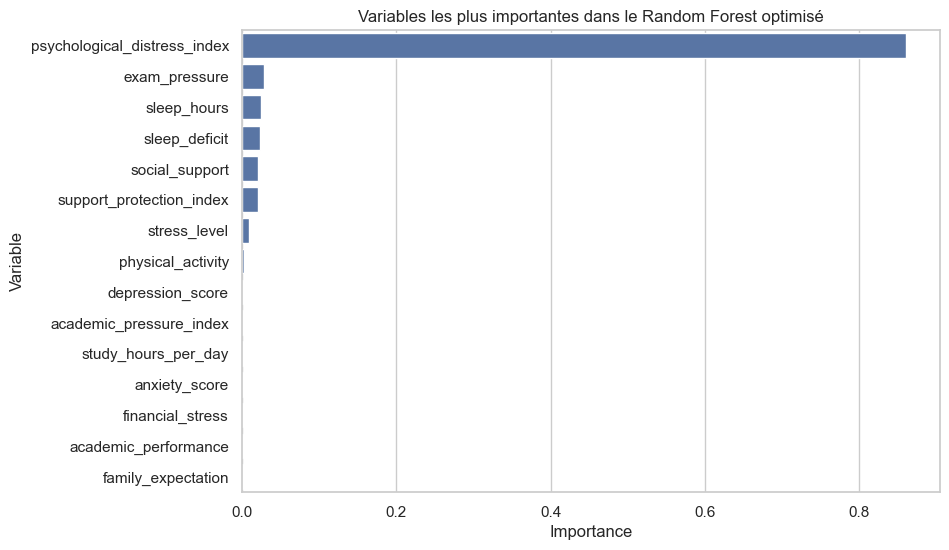

In [34]:
# Visualisation des 15 variables les plus importantes
top_features = feature_importance_df.head(15).copy()

# Nettoyage des noms pour l'affichage
top_features["Variable"] = top_features["Variable"].str.replace("num__", "", regex=False)
top_features["Variable"] = top_features["Variable"].str.replace("cat__", "", regex=False)

plt.figure(figsize=(9, 6))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Variable"
)
plt.title("Variables les plus importantes dans le Random Forest optimisé")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.show()

### Interprétation graphique de l’importance des variables

Le graphique confirme que le `psychological_distress_index` domine très fortement l’importance des variables dans le Random Forest optimisé.  
Cette variable synthétique regroupe le stress, l’anxiété et la dépression, ce qui explique son poids élevé dans la prédiction du `burnout_score`.

Les variables suivantes ont une importance beaucoup plus faible, mais restent cohérentes avec l’analyse exploratoire : `exam_pressure`, `sleep_hours`, `sleep_deficit`, `social_support` et `support_protection_index`.  
Elles traduisent le rôle complémentaire de la pression académique, du sommeil et du soutien social dans l’explication du burnout.

Cette forte domination du `psychological_distress_index` montre que le modèle s’appuie principalement sur une dimension globale de détresse psychologique.  
Cela constitue un résultat pertinent, mais aussi une limite à discuter : lorsqu’une variable synthétique concentre une grande partie de l’information, elle peut masquer l’importance individuelle des variables qui la composent.

Pour cette raison, l’interprétation ne doit pas se limiter au score d’importance du modèle.  
Elle doit être complétée par les analyses précédentes, qui ont montré séparément le rôle du stress, de l’anxiété, de la dépression, du sommeil, du soutien social et de la pression académique.

## 25. Synthèse de la modélisation par régression

La phase de régression avait pour objectif de prédire le score quantitatif de burnout (`burnout_score`) à partir des variables académiques, comportementales et psychosociales du dataset.

Les résultats montrent que la régression linéaire constitue une baseline solide, avec un $R^2$ d’environ **0.71**.  
Cela indique qu’une part importante de la variance du score de burnout peut déjà être expliquée par des relations linéaires entre les variables.

L’ajout des variables issues du feature engineering améliore légèrement la régression linéaire.  
Cette amélioration reste faible sur le plan prédictif, mais elle est pertinente sur le plan explicatif, car les variables construites permettent de résumer des dimensions importantes du risque : détresse psychologique, pression académique, déficit de sommeil et facteurs protecteurs.

Le Random Forest optimisé obtient les meilleures performances, avec un $R^2 = 0.7375$, un RMSE de **0.8522** et un MAE de **0.6460**.  
Ce gain par rapport au modèle linéaire suggère que certaines relations entre les variables et le burnout ne sont pas strictement linéaires.

L’analyse de l’importance des variables montre que le `psychological_distress_index` est le facteur dominant dans la prédiction du burnout.  
Les variables liées au sommeil, à la pression académique et au soutien social jouent également un rôle complémentaire.

Ces résultats confirment que le burnout étudiant, dans ce dataset, est principalement associé à la détresse psychologique, mais qu’il s’inscrit aussi dans un équilibre plus large entre contraintes académiques et facteurs protecteurs.  
La suite du projet se concentre désormais sur la classification du niveau de risque (`risk_level`), avec une attention particulière portée à la détection de la classe `High`, fortement minoritaire.

## 26. Préparation des données pour la classification

L’objectif est maintenant de prédire la variable `risk_level`, qui correspond au niveau de risque de burnout (`Low`, `Medium`, `High`).

Cette tâche est différente de la régression précédente : il ne s’agit plus d’estimer un score continu, mais d’assigner chaque étudiant à une classe de risque.

Une attention particulière sera portée au déséquilibre des classes, puisque la classe `High` est fortement minoritaire. L’évaluation ne reposera donc pas uniquement sur l’accuracy, mais aussi sur le F1-score macro, le rappel de la classe `High` et la matrice de confusion.

In [35]:
# Variable cible pour la classification
target_clf = "risk_level"

# Variables exclues pour éviter les fuites de données
excluded_cols_clf = [
    "risk_level",
    "burnout_score",
    "mental_health_index",
    "dropout_risk"
]

# Jeu de variables initiales
X_clf_base = df.drop(columns=excluded_cols_clf)
y_clf = df[target_clf]

# Jeu de variables enrichies avec feature engineering
X_clf_fe = df_fe.drop(columns=excluded_cols_clf)
y_clf_fe = df_fe[target_clf]

print("Dimensions X_clf_base :", X_clf_base.shape)
print("Dimensions X_clf_fe :", X_clf_fe.shape)
print("Dimensions y_clf :", y_clf.shape)

print("\nDistribution de la cible :")
print(y_clf.value_counts(normalize=True).round(4) * 100)

Dimensions X_clf_base : (1000000, 16)
Dimensions X_clf_fe : (1000000, 21)
Dimensions y_clf : (1000000,)

Distribution de la cible :
risk_level
Low       76.66
Medium    21.83
High       1.51
Name: proportion, dtype: float64


### Interprétation de la préparation des données de classification

La variable cible de cette partie est `risk_level`, qui correspond au niveau de risque de burnout selon trois modalités : `Low`, `Medium` et `High`.

Deux jeux de variables ont été préparés :

- `X_clf_base`, composé de **16 variables explicatives initiales** ;
- `X_clf_fe`, composé de **21 variables explicatives**, incluant les variables créées lors du feature engineering.

Les variables `burnout_score`, `mental_health_index` et `dropout_risk` ont été exclues afin d’éviter une fuite d’information.  
Ces variables sont très proches du risque étudié ou directement liées à sa construction. Les conserver aurait rendu la classification artificiellement plus simple et aurait faussé l’évaluation du modèle.

La distribution de la variable cible confirme un fort déséquilibre des classes : la classe `Low` représente **76,66 %** des observations, la classe `Medium` **21,83 %**, et la classe `High` seulement **1,51 %**.  
La suite de la classification devra donc privilégier des métriques adaptées, notamment le F1-score macro, le rappel de la classe `High` et la matrice de confusion.

## 27. Découpage train / validation / test pour la classification

Pour la classification, les données sont séparées en trois sous-ensembles :

- un jeu d’apprentissage, utilisé pour entraîner les modèles ;
- un jeu de validation, utilisé pour comparer les modèles et ajuster certains choix méthodologiques ;
- un jeu de test, conservé pour l’évaluation finale.

Le découpage est stratifié selon la variable `risk_level`, afin de conserver la même proportion de classes dans chaque sous-ensemble.  
Cette précaution est importante, car la classe `High` est fortement minoritaire.

In [36]:
# Premier split : 80 % train + validation, 20 % test
X_temp_clf, X_test_clf, y_temp_clf, y_test_clf = train_test_split(
    X_clf_fe,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

# Deuxième split : 60 % train, 20 % validation, 20 % test au total
X_train_clf, X_val_clf, y_train_clf, y_val_clf = train_test_split(
    X_temp_clf,
    y_temp_clf,
    test_size=0.25,
    random_state=42,
    stratify=y_temp_clf
)

print("Train :", X_train_clf.shape)
print("Validation :", X_val_clf.shape)
print("Test :", X_test_clf.shape)

print("\nDistribution train :")
print(y_train_clf.value_counts(normalize=True).round(4) * 100)

print("\nDistribution validation :")
print(y_val_clf.value_counts(normalize=True).round(4) * 100)

print("\nDistribution test :")
print(y_test_clf.value_counts(normalize=True).round(4) * 100)

Train : (600000, 21)
Validation : (200000, 21)
Test : (200000, 21)

Distribution train :
risk_level
Low       76.66
Medium    21.83
High       1.51
Name: proportion, dtype: float64

Distribution validation :
risk_level
Low       76.66
Medium    21.83
High       1.51
Name: proportion, dtype: float64

Distribution test :
risk_level
Low       76.66
Medium    21.83
High       1.51
Name: proportion, dtype: float64


### Interprétation du découpage train / validation / test

Le jeu de données a été séparé en trois sous-ensembles :

- **600 000 observations** pour l’apprentissage ;
- **200 000 observations** pour la validation ;
- **200 000 observations** pour le test.

Ce découpage permet de distinguer clairement les étapes du processus de modélisation.  
Le jeu d’apprentissage sert à entraîner les modèles, le jeu de validation permet de comparer les modèles et d’ajuster certains paramètres, tandis que le jeu de test reste réservé à l’évaluation finale.

Le découpage a été réalisé avec stratification sur la variable `risk_level`.  
Les distributions obtenues sont identiques dans les trois sous-ensembles : **76,66 %** pour `Low`, **21,83 %** pour `Medium` et **1,51 %** pour `High`.

Cette stratification est essentielle dans ce projet, car la classe `High` est fortement minoritaire.  
Elle garantit que les trois ensembles conservent une représentation cohérente des profils à risque élevé, ce qui rend l’évaluation plus fiable.

## 28. Baseline de classification : modèle majoritaire

Avant d’entraîner des modèles plus complexes, une baseline simple est construite avec un classifieur naïf.

Ce modèle prédit systématiquement la classe la plus fréquente, c’est-à-dire `Low`.  
Il permet de montrer pourquoi l’accuracy seule peut être trompeuse dans un contexte de classes déséquilibrées.

Si un modèle plus complexe n’améliore pas réellement cette baseline, notamment sur la détection de la classe `High`, son intérêt est limité.

In [37]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score, precision_score

# Baseline naïve : prédiction de la classe majoritaire
dummy_clf = DummyClassifier(strategy="most_frequent")

dummy_clf.fit(X_train_clf, y_train_clf)

y_pred_dummy = dummy_clf.predict(X_val_clf)

print("Baseline DummyClassifier")
print("Accuracy :", accuracy_score(y_val_clf, y_pred_dummy))
print("F1 macro :", f1_score(y_val_clf, y_pred_dummy, average="macro"))
print("\nRapport de classification :")
print(classification_report(y_val_clf, y_pred_dummy))

Baseline DummyClassifier
Accuracy : 0.766645
F1 macro : 0.2893035480623819

Rapport de classification :


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

        High       0.00      0.00      0.00      3016
         Low       0.77      1.00      0.87    153329
      Medium       0.00      0.00      0.00     43655

    accuracy                           0.77    200000
   macro avg       0.26      0.33      0.29    200000
weighted avg       0.59      0.77      0.67    200000



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Interprétation de la baseline de classification

Le `DummyClassifier` prédit systématiquement la classe majoritaire `Low`.  
Il obtient une accuracy de **0.7666**, soit environ **76,7 %**, ce qui correspond directement à la proportion de la classe `Low` dans le jeu de validation.

Ce résultat montre clairement le caractère trompeur de l’accuracy dans un contexte de classes déséquilibrées.  
Même sans apprendre aucune relation entre les variables, le modèle obtient une accuracy élevée simplement parce qu’il prédit toujours la classe dominante.

En revanche, les performances par classe montrent que ce modèle est inutile pour l’objectif du projet.  
Le recall, la precision et le F1-score des classes `Medium` et `High` sont égaux à **0**, car ces classes ne sont jamais prédites.  
En particulier, aucun étudiant à risque élevé (`High`) n’est détecté.

Le F1-score macro est faible (**0.2893**), car cette métrique donne le même poids à chaque classe.  
Elle met donc en évidence l’échec du modèle sur les classes minoritaires, contrairement à l’accuracy.

Cette baseline confirme que les modèles suivants devront être évalués prioritairement avec des métriques adaptées, notamment le F1-score macro, le recall de la classe `High` et la matrice de confusion.

## 29. Modèle de classification interprétable : régression logistique pondérée

La régression logistique est utilisée comme premier modèle supervisé interprétable pour prédire `risk_level`.

Contrairement à la baseline naïve, ce modèle apprend une relation entre les variables explicatives et les classes de risque.  
Comme les classes sont déséquilibrées, l’option `class_weight="balanced"` est utilisée afin de donner plus de poids aux classes minoritaires, notamment la classe `High`.

Ce modèle servira de référence interprétable avant de tester des modèles plus complexes.

In [38]:
from sklearn.linear_model import LogisticRegression

# Variables catégorielles et numériques
cat_features_clf = X_train_clf.select_dtypes(exclude=np.number).columns.tolist()
num_features_clf = X_train_clf.select_dtypes(include=np.number).columns.tolist()

# Prétraitement classification
preprocessor_clf = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features_clf),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features_clf)
    ]
)

# Régression logistique pondérée
log_reg_balanced = Pipeline(
    steps=[
        ("preprocessor", preprocessor_clf),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

# Entraînement
log_reg_balanced.fit(X_train_clf, y_train_clf)

# Prédictions sur validation
y_pred_log_reg = log_reg_balanced.predict(X_val_clf)

# Évaluation
print("Régression logistique pondérée")
print("Accuracy :", accuracy_score(y_val_clf, y_pred_log_reg))
print("F1 macro :", f1_score(y_val_clf, y_pred_log_reg, average="macro"))
print("Recall High :", recall_score(y_val_clf, y_pred_log_reg, labels=["High"], average="macro"))
print("\nRapport de classification :")
print(classification_report(y_val_clf, y_pred_log_reg, zero_division=0))

Régression logistique pondérée
Accuracy : 0.80694
F1 macro : 0.6320551286304733
Recall High : 0.8464854111405835

Rapport de classification :
              precision    recall  f1-score   support

        High       0.25      0.85      0.39      3016
         Low       0.95      0.84      0.89    153329
      Medium       0.55      0.69      0.61     43655

    accuracy                           0.81    200000
   macro avg       0.59      0.79      0.63    200000
weighted avg       0.85      0.81      0.82    200000



### Interprétation de la régression logistique pondérée

La régression logistique pondérée améliore nettement les performances par rapport à la baseline naïve.  
L’accuracy passe de **0.7666** à **0.8069**, mais l’amélioration la plus importante concerne surtout les métriques adaptées aux classes déséquilibrées.

Le F1-score macro atteint **0.6321**, contre **0.2893** pour la baseline.  
Cela montre que le modèle ne se contente plus de prédire la classe majoritaire `Low`, mais parvient également à identifier une partie importante des classes minoritaires.

Le résultat le plus important concerne la classe `High`.  
Le recall de cette classe atteint **0.8465**, ce qui signifie que le modèle détecte environ **84,6 %** des étudiants réellement classés à haut risque.  
Ce résultat est très pertinent dans une logique de prévention, car l’objectif principal est de limiter les faux négatifs sur les profils les plus vulnérables.

Cependant, la précision de la classe `High` reste faible (**0.25**).  
Cela signifie que parmi les étudiants prédits comme `High`, une partie importante appartient en réalité à une autre classe.  
Le modèle privilégie donc la détection des profils à risque, mais au prix d’un nombre plus élevé de faux positifs.

Cette logique peut être acceptable dans un contexte de prévention, où il est souvent préférable de signaler davantage de profils potentiellement à risque plutôt que de manquer des étudiants réellement vulnérables.  
La régression logistique pondérée constitue donc une baseline supervisée solide et interprétable.

## 30. Modèle non linéaire : Random Forest Classifier pondéré

Après la régression logistique, un modèle Random Forest est testé pour la classification du niveau de risque.

Ce modèle permet de capturer des relations non linéaires entre les variables et les classes de risque.  
Comme pour la régression logistique, une pondération des classes est utilisée afin de tenir compte du déséquilibre de `risk_level`.

L’objectif est de vérifier si un modèle plus flexible améliore la détection des profils à risque, notamment la classe `High`.

In [39]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Classifier pondéré
rf_clf_balanced = Pipeline(
    steps=[
        ("preprocessor", preprocessor_clf),
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Entraînement
rf_clf_balanced.fit(X_train_clf, y_train_clf)

# Prédictions sur validation
y_pred_rf_clf = rf_clf_balanced.predict(X_val_clf)

# Évaluation
print("Random Forest Classifier pondéré")
print("Accuracy :", accuracy_score(y_val_clf, y_pred_rf_clf))
print("F1 macro :", f1_score(y_val_clf, y_pred_rf_clf, average="macro"))
print("Recall High :", recall_score(y_val_clf, y_pred_rf_clf, labels=["High"], average="macro"))
print("\nRapport de classification :")
print(classification_report(y_val_clf, y_pred_rf_clf, zero_division=0))

Random Forest Classifier pondéré
Accuracy : 0.810755
F1 macro : 0.6576766419973111
Recall High : 0.7446949602122016

Rapport de classification :
              precision    recall  f1-score   support

        High       0.32      0.74      0.45      3016
         Low       0.96      0.83      0.89    153329
      Medium       0.55      0.76      0.64     43655

    accuracy                           0.81    200000
   macro avg       0.61      0.78      0.66    200000
weighted avg       0.86      0.81      0.83    200000



### Interprétation du Random Forest Classifier pondéré

Le Random Forest Classifier pondéré obtient une accuracy de **0.8108**, légèrement supérieure à celle de la régression logistique pondérée (**0.8069**).  
Le F1-score macro atteint **0.6577**, contre **0.6321** pour la régression logistique. Cela indique une meilleure performance moyenne entre les trois classes.

Pour la classe `High`, le recall est de **0.7447**.  
Le modèle détecte donc environ **74,5 %** des étudiants réellement à haut risque. Ce score est inférieur à celui de la régression logistique pondérée, qui atteignait **84,6 %**.

En revanche, la précision de la classe `High` augmente, passant de **0.25** avec la régression logistique à **0.32** avec le Random Forest.  
Cela signifie que le Random Forest produit moins de faux positifs lorsqu’il prédit la classe `High`, mais il manque davantage de vrais étudiants à haut risque.

Le Random Forest présente donc un compromis différent : il améliore le F1-score global et la précision de la classe `High`, mais réduit le rappel de cette classe.  
Dans une logique de prévention, ce compromis doit être discuté, car manquer des profils réellement à risque peut être plus problématique que produire quelques alertes supplémentaires.

À ce stade, la régression logistique pondérée semble plus adaptée si l’objectif principal est de maximiser la détection des étudiants à haut risque, tandis que le Random Forest pondéré offre un meilleur équilibre global entre précision et rappel.

## 31. Comparaison des premiers modèles de classification

Les premiers modèles de classification sont comparés sur le jeu de validation.

La comparaison ne repose pas uniquement sur l’accuracy.  
Dans ce projet, les métriques les plus importantes sont le F1-score macro et le recall de la classe `High`, car la classe à haut risque est fortement minoritaire.

In [40]:
# Fonction pour récupérer les métriques principales
def classification_metrics(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return {
        "Modèle": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1 macro": f1_score(y_true, y_pred, average="macro"),
        "Precision High": report["High"]["precision"],
        "Recall High": report["High"]["recall"],
        "F1 High": report["High"]["f1-score"]
    }

results_clf = pd.DataFrame([
    classification_metrics(y_val_clf, y_pred_dummy, "DummyClassifier"),
    classification_metrics(y_val_clf, y_pred_log_reg, "Régression logistique pondérée"),
    classification_metrics(y_val_clf, y_pred_rf_clf, "Random Forest pondéré")
]).sort_values(by="F1 macro", ascending=False)

results_clf

,Modèle,Accuracy,F1 macro,Precision High,Recall High,F1 High
2,Random Forest pondéré,0.810755,0.657677,0.321408,0.744695,0.449020
1,Régression logistique pondérée,0.806940,0.632055,0.254816,0.846485,0.391715
0,DummyClassifier,0.766645,0.289304,0.000000,0.000000,0.000000


### Interprétation de la comparaison des modèles de classification

La comparaison des premiers modèles de classification montre que les modèles supervisés améliorent nettement la baseline naïve.

Le `DummyClassifier` obtient une accuracy élevée de **0.7666**, mais son F1-score macro est très faible (**0.2893**) et il ne détecte aucun étudiant de la classe `High`.  
Cela confirme que l’accuracy seule est insuffisante dans ce projet, car elle reflète principalement la classe majoritaire `Low`.

Le Random Forest pondéré obtient le meilleur F1-score macro (**0.6577**) et le meilleur F1-score pour la classe `High` (**0.4490**).  
Il présente donc le meilleur équilibre global entre les trois classes.

La régression logistique pondérée obtient un recall plus élevé pour la classe `High` (**0.8465**), contre **0.7447** pour le Random Forest.  
Elle détecte donc davantage d’étudiants réellement à haut risque, mais avec une précision plus faible (**0.2548**), ce qui signifie qu’elle génère plus de faux positifs.

Le choix du modèle dépend donc de l’objectif prioritaire.  
Si l’objectif est de maximiser la détection des étudiants à haut risque, la régression logistique pondérée est intéressante.  
Si l’objectif est d’obtenir un meilleur équilibre entre précision, rappel et performance globale, le Random Forest pondéré est plus adapté.

À ce stade, le Random Forest pondéré apparaît comme le meilleur compromis global, mais la régression logistique reste importante pour une logique de prévention centrée sur le rappel de la classe `High`.

## 32. Matrice de confusion du Random Forest pondéré

La matrice de confusion permet d’analyser plus précisément les erreurs de classification.  
Elle montre quelles classes sont correctement prédites et quelles confusions apparaissent entre les niveaux de risque.

Cette étape est particulièrement importante pour la classe `High`, car l’enjeu du projet est de détecter les étudiants les plus à risque.

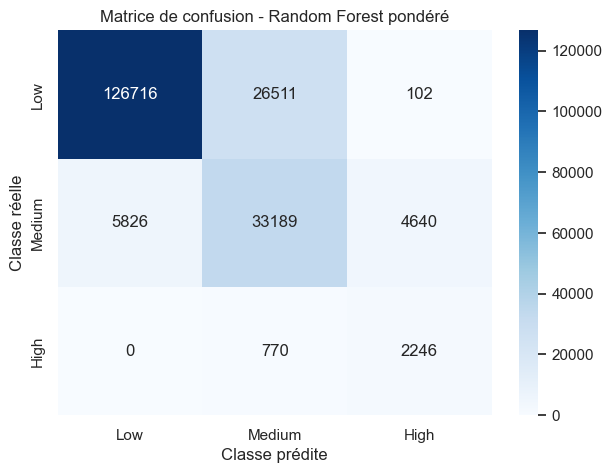

In [41]:
# Matrice de confusion pour le Random Forest pondéré
labels_order = ["Low", "Medium", "High"]

cm_rf = confusion_matrix(y_val_clf, y_pred_rf_clf, labels=labels_order)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_order,
    yticklabels=labels_order
)
plt.title("Matrice de confusion - Random Forest pondéré")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

### Interprétation de la matrice de confusion

La matrice de confusion du Random Forest pondéré permet de mieux comprendre les erreurs du modèle.

Pour la classe `Low`, le modèle classe correctement **126 716** observations sur **153 329**.  
Cependant, **26 511** étudiants réellement `Low` sont prédits comme `Medium`, ce qui montre que le modèle tend parfois à surévaluer le niveau de risque. Les confusions entre `Low` et `High` restent très faibles, avec seulement **102** cas.

Pour la classe `Medium`, **33 189** observations sont correctement classées.  
Le modèle confond une partie des étudiants `Medium` avec la classe `Low` (**5 826** cas) et une autre partie avec la classe `High` (**4 640** cas). Cette classe intermédiaire est donc plus difficile à distinguer, ce qui est logique car elle se situe entre les profils faibles et élevés.

Pour la classe `High`, le modèle identifie correctement **2 246** observations sur **3 016**.  
Il ne classe aucun étudiant réellement `High` en `Low`, ce qui est un résultat important dans une logique de prévention.  
Les erreurs restantes concernent principalement des étudiants `High` prédits comme `Medium` (**770** cas).

Cette matrice montre donc que le modèle détecte une grande partie des profils à haut risque, tout en limitant les confusions directes entre `High` et `Low`.  
La principale limite concerne la séparation entre les classes voisines, notamment entre `Medium` et `High`.

Dans une perspective de prévention du burnout, ce résultat est intéressant : le modèle manque encore certains profils `High`, mais il les classe généralement dans une catégorie de risque intermédiaire plutôt que dans la catégorie faible.

## 33. Matrice de confusion de la régression logistique pondérée

La régression logistique pondérée a obtenu le meilleur rappel pour la classe `High`.  
Il est donc utile d’analyser sa matrice de confusion afin de comprendre le type d’erreurs qu’elle produit et de la comparer au Random Forest pondéré.

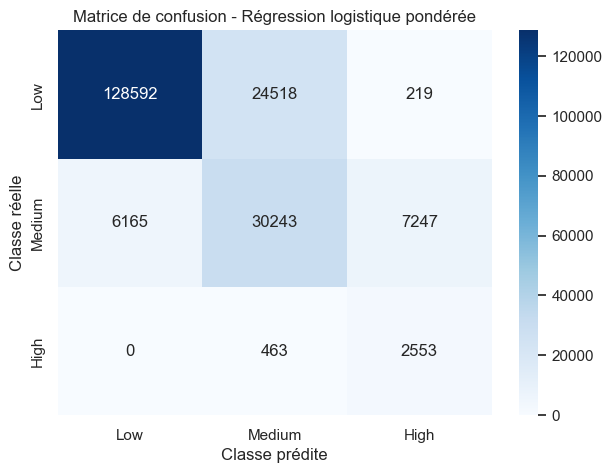

In [42]:
# Matrice de confusion pour la régression logistique pondérée
cm_log = confusion_matrix(y_val_clf, y_pred_log_reg, labels=labels_order)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_order,
    yticklabels=labels_order
)
plt.title("Matrice de confusion - Régression logistique pondérée")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

### Interprétation de la matrice de confusion de la régression logistique pondérée

La matrice de confusion de la régression logistique pondérée montre que le modèle détecte correctement **2 553** étudiants `High` sur **3 016**, soit un rappel très élevé pour la classe à risque.

Aucun étudiant réellement `High` n’est classé en `Low`.  
Les erreurs concernant cette classe correspondent donc uniquement à des confusions avec la classe `Medium` (**463** cas).  
Ce résultat est important dans une logique de prévention, car le modèle évite de considérer des profils à haut risque comme des profils à faible risque.

Pour la classe `Low`, le modèle classe correctement **128 592** observations sur **153 329**.  
Il confond cependant **24 518** étudiants `Low` avec la classe `Medium` et **219** avec la classe `High`.  
Cela montre que le modèle peut parfois surestimer le niveau de risque.

Pour la classe `Medium`, **30 243** observations sont correctement classées.  
Une partie des étudiants `Medium` est prédite comme `Low` (**6 165** cas), tandis qu’une autre partie est prédite comme `High` (**7 247** cas).  
La classe intermédiaire reste donc la plus difficile à séparer, car elle se situe entre les profils peu vulnérables et les profils fortement à risque.

Comparée au Random Forest pondéré, la régression logistique détecte davantage d’étudiants réellement `High` (**2 553** contre **2 246**).  
En revanche, elle génère davantage de prédictions `High` erronées, notamment pour des étudiants réellement `Medium`.

Ainsi, la régression logistique pondérée privilégie le rappel de la classe `High`, tandis que le Random Forest pondéré offre un meilleur équilibre global entre précision et rappel.  
Dans un contexte de prévention du burnout, cette différence est importante : si l’objectif principal est de ne pas manquer les étudiants les plus vulnérables, la régression logistique pondérée reste très pertinente.

## 34. Synthèse intermédiaire des modèles de classification

Les premiers modèles de classification ont permis de comparer plusieurs approches pour prédire le niveau de risque de burnout (`risk_level`).

La baseline naïve montre que l’accuracy peut être trompeuse dans un contexte déséquilibré : prédire toujours la classe majoritaire `Low` permet d’obtenir environ 76,7 % d’accuracy, mais ne détecte aucun étudiant `High`.

Les modèles pondérés améliorent nettement cette situation.  
La régression logistique pondérée obtient le meilleur rappel pour la classe `High`, tandis que le Random Forest pondéré obtient le meilleur F1-score macro et le meilleur F1-score pour la classe `High`.

Cette comparaison montre qu’il n’existe pas un seul “meilleur” modèle indépendamment de l’objectif.  
Dans une logique de prévention, le rappel de la classe `High` est prioritaire, car il mesure la capacité du modèle à détecter les étudiants réellement à haut risque.  
Dans une logique d’équilibre global, le F1-score macro permet d’évaluer la performance moyenne sur les trois classes.

À ce stade, deux limites apparaissent :

- les modèles standards restent sensibles au déséquilibre des classes ;
- les métriques globales ne suffisent pas à répondre à l’objectif métier, qui est de mieux identifier les profils les plus vulnérables.

La suite du projet propose donc une approche complémentaire fondée sur un score explicatif de vulnérabilité au burnout.

## 35. Proposition d’un score explicatif de vulnérabilité

Les modèles précédents permettent de prédire le niveau de risque, mais leur interprétation reste limitée par deux éléments : le déséquilibre des classes et la difficulté à prioriser les étudiants réellement à haut risque.

Afin de dépasser une simple application de modèles standards, une approche complémentaire est proposée : la construction d’un score explicatif de vulnérabilité au burnout.

Ce score combine plusieurs dimensions identifiées dans l’analyse exploratoire :

- la détresse psychologique ;
- la pression académique ;
- le déficit de sommeil ;
- les facteurs protecteurs, comme le soutien social, le sommeil et l’activité physique.

L’objectif n’est pas nécessairement d’obtenir une amélioration massive des performances, mais de proposer un indicateur interprétable, cohérent avec les résultats exploratoires, et orienté vers la détection des profils les plus vulnérables.

In [43]:
from sklearn.preprocessing import MinMaxScaler

# Copie du dataset enrichi
df_vuln = df_fe.copy()

# Création d'un score brut de vulnérabilité
df_vuln["vulnerability_score_raw"] = (
    df_vuln["psychological_distress_index"]
    + df_vuln["academic_pressure_index"]
    + df_vuln["sleep_deficit"]
    - df_vuln["support_protection_index"]
)

# Normalisation entre 0 et 1 pour faciliter l'interprétation
scaler_vuln = MinMaxScaler()
df_vuln["vulnerability_score"] = scaler_vuln.fit_transform(
    df_vuln[["vulnerability_score_raw"]]
)

df_vuln[["vulnerability_score_raw", "vulnerability_score", "risk_level", "burnout_score"]].describe().T

,count,mean,std,min,25%,50%,75%,max
vulnerability_score_raw,1000000.0,5.277811,3.205765,-7.184628,3.014678,5.177035,7.435496,20.706405
vulnerability_score,1000000.0,0.446826,0.114939,0.000000,0.365684,0.443213,0.524187,1.000000
burnout_score,1000000.0,1.784073,1.664035,0.000000,0.124810,1.496505,2.889473,10.000000


### Interprétation du score explicatif de vulnérabilité

Le score explicatif de vulnérabilité a été construit à partir de plusieurs dimensions identifiées comme importantes dans l’analyse exploratoire : la détresse psychologique, la pression académique, le déficit de sommeil et les facteurs protecteurs.

Le score brut `vulnerability_score_raw` présente une moyenne de **5.28** et un écart-type de **3.21**.  
Il varie entre **-7.18** et **20.71**, ce qui montre qu’il permet de distinguer des profils très différents : certains étudiants cumulent peu de facteurs de risque, tandis que d’autres présentent une vulnérabilité plus élevée.

Afin de faciliter l’interprétation, ce score a été normalisé entre **0** et **1** dans la variable `vulnerability_score`.  
Sa moyenne est de **0.45**, avec une médiane proche de **0.44**.  
Plus le score est élevé, plus l’étudiant présente une combinaison défavorable de facteurs associés au burnout.

Ce score ne remplace pas les modèles de classification.  
Il constitue une proposition complémentaire et interprétable, visant à mieux structurer la détection des profils vulnérables.  
La suite de l’analyse évaluera s’il est effectivement associé au `burnout_score` et s’il permet de mieux repérer les étudiants de la classe `High`.

## 36. Analyse du lien entre le score de vulnérabilité et le burnout

Après la construction du score de vulnérabilité, il est nécessaire d’évaluer son lien avec le score de burnout et avec les classes de risque.

Cette étape permet de vérifier si le score proposé est cohérent avec l’objectif du projet : identifier les profils les plus vulnérables.

In [44]:
# Corrélation entre le score de vulnérabilité et le burnout
corr_vuln_burnout = df_vuln[["vulnerability_score", "burnout_score"]].corr().iloc[0, 1]

print(f"Corrélation vulnerability_score / burnout_score : {corr_vuln_burnout:.4f}")

Corrélation vulnerability_score / burnout_score : 0.7708


In [45]:
# Comparaison du score de vulnérabilité selon risk_level
df_vuln.groupby("risk_level")["vulnerability_score"].describe()

,count,mean,std,min,25%,50%,75%,max
risk_level,,,,,,,,
High,15080.0,0.686190,0.076094,0.373304,0.634753,0.685302,0.738183,1.000000
Low,766645.0,0.409276,0.094698,0.000000,0.344076,0.410276,0.475017,0.805272
Medium,218275.0,0.562176,0.080066,0.243232,0.506508,0.561132,0.616673,0.936692


### Interprétation du lien entre score de vulnérabilité et burnout

Le score de vulnérabilité présente une forte corrélation positive avec le `burnout_score` :  
$ r = 0.7708 $.

Cela signifie que plus le score de vulnérabilité augmente, plus le score de burnout tend également à augmenter.  
Ce résultat confirme que le score proposé est cohérent avec l’objectif du projet, puisqu’il résume des dimensions fortement associées au burnout : détresse psychologique, pression académique, déficit de sommeil et facteurs protecteurs.

L’analyse par classe de risque confirme également la pertinence du score.  
La moyenne du `vulnerability_score` augmente nettement selon le niveau de risque :

- `Low` : moyenne de **0.4093** ;
- `Medium` : moyenne de **0.5622** ;
- `High` : moyenne de **0.6862**.

Les médianes suivent la même progression : environ **0.4103** pour `Low`, **0.5611** pour `Medium` et **0.6853** pour `High`.

Cette progression montre que le score distingue bien les trois catégories de risque.  
Les étudiants classés `High` présentent en moyenne un score de vulnérabilité nettement plus élevé que les autres groupes.

Ce résultat valide l’intérêt de la proposition : le score de vulnérabilité constitue un indicateur synthétique, interprétable et cohérent avec la structure du dataset.  
Il peut maintenant être évalué comme outil complémentaire pour repérer les profils les plus vulnérables.

## 37. Visualisation du score de vulnérabilité selon le niveau de risque

La distribution du score de vulnérabilité est comparée selon les trois classes de risque.  
Cette visualisation permet de vérifier si le score proposé sépare effectivement les profils `Low`, `Medium` et `High`.

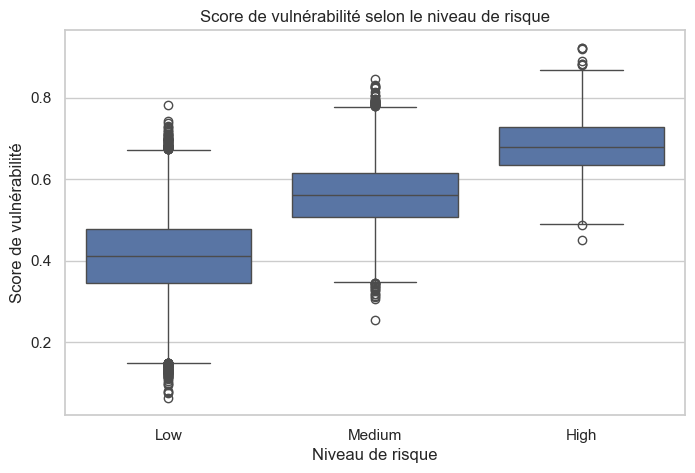

In [46]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_vuln.sample(n=50000, random_state=42),
    x="risk_level",
    y="vulnerability_score",
    order=["Low", "Medium", "High"]
)
plt.title("Score de vulnérabilité selon le niveau de risque")
plt.xlabel("Niveau de risque")
plt.ylabel("Score de vulnérabilité")
plt.show()

### Interprétation du score de vulnérabilité selon `risk_level`

Le boxplot confirme que le score de vulnérabilité distingue clairement les trois niveaux de risque.

Les étudiants classés `Low` présentent les scores les plus faibles, avec une médiane autour de **0.41**.  
Les étudiants classés `Medium` ont un score intermédiaire, avec une médiane proche de **0.56**.  
Enfin, les étudiants classés `High` présentent les scores les plus élevés, avec une médiane autour de **0.69**.

Cette progression régulière montre que le score proposé est cohérent avec la structure de la variable `risk_level`.  
Plus le niveau de risque augmente, plus le score de vulnérabilité augmente également.

On observe toutefois un certain chevauchement entre les distributions, notamment entre `Low` et `Medium`, puis entre `Medium` et `High`.  
Cela signifie que le score ne sépare pas parfaitement les classes, mais il fournit une information synthétique pertinente pour repérer les profils les plus vulnérables.

Ce résultat est important pour le projet : le score de vulnérabilité ne constitue pas seulement une variable supplémentaire, mais une proposition interprétable permettant de relier la prédiction à des dimensions concrètes du burnout étudiant.

## 38. Évaluation du score comme outil de détection des profils à risque

Le score de vulnérabilité peut également être évalué comme un outil simple de priorisation.

L’idée est d’identifier les étudiants ayant les scores les plus élevés, puis de mesurer quelle proportion des étudiants réellement classés `High` est capturée dans ce groupe.

Cette approche ne cherche pas à remplacer les modèles de classification, mais à proposer un indicateur interprétable permettant de repérer les profils potentiellement les plus vulnérables.

In [47]:
# Seuil correspondant aux 5 % des scores de vulnérabilité les plus élevés
threshold_95 = df_vuln["vulnerability_score"].quantile(0.95)

# Étudiants identifiés comme vulnérables selon le score
df_vuln["top_5_vulnerability"] = df_vuln["vulnerability_score"] >= threshold_95

# Nombre total d'étudiants High
total_high = (df_vuln["risk_level"] == "High").sum()

# Nombre de High capturés dans le top 5 %
high_captured = ((df_vuln["risk_level"] == "High") & (df_vuln["top_5_vulnerability"])).sum()

# Taux de capture des High
capture_rate_high = high_captured / total_high

print("Seuil top 5 % :", round(threshold_95, 4))
print("Nombre total de High :", total_high)
print("Nombre de High capturés dans le top 5 % :", high_captured)
print("Taux de capture des High :", round(capture_rate_high * 100, 2), "%")

Seuil top 5 % : 0.6423
Nombre total de High : 15080
Nombre de High capturés dans le top 5 % : 10795
Taux de capture des High : 71.58 %


### Interprétation du taux de capture des profils `High`

Le score de vulnérabilité permet d’identifier les **5 % d’étudiants les plus vulnérables** selon les dimensions psychologiques, académiques et protectrices construites précédemment.

Le seuil correspondant au top 5 % est de **0.6423**.  
Parmi les **15 080** étudiants réellement classés `High`, **10 795** sont capturés dans ce groupe prioritaire.

Le taux de capture des étudiants `High` atteint donc **71,58 %**.

Ce résultat est important, car il montre qu’un score simple et interprétable permet de repérer une grande partie des profils les plus à risque, sans utiliser directement un modèle complexe de classification.  
Dans une logique de prévention, cette approche peut être utile pour prioriser les étudiants nécessitant une attention particulière.

Cependant, cette méthode ne capture pas tous les étudiants `High`.  
Environ **28,42 %** des profils à haut risque ne sont pas identifiés dans le top 5 %.  
Le score de vulnérabilité doit donc être interprété comme un outil complémentaire de priorisation, et non comme un outil de classification parfait.

Cette analyse confirme l’intérêt de la proposition : le score apporte une lecture explicative et opérationnelle du risque, tout en permettant d’évaluer concrètement sa capacité à repérer les profils les plus vulnérables.

## 39. Composition du groupe identifié comme le plus vulnérable

Après avoir mesuré le taux de capture des étudiants `High`, il est nécessaire d’analyser la composition du groupe des 5 % les plus vulnérables.

Cette étape permet de vérifier si le score identifie principalement des profils réellement à haut risque, ou s’il inclut aussi des étudiants `Medium` et `Low`.

In [48]:
# Composition du top 5 % selon risk_level
top5_composition = df_vuln[df_vuln["top_5_vulnerability"]]["risk_level"].value_counts()
top5_composition_pct = df_vuln[df_vuln["top_5_vulnerability"]]["risk_level"].value_counts(normalize=True) * 100

print("Composition brute du top 5 % :")
print(top5_composition)

print("\nComposition en pourcentage du top 5 % :")
print(top5_composition_pct.round(2))


Composition brute du top 5 % :
risk_level
Medium    35278
High      10795
Low        3927
Name: count, dtype: int64

Composition en pourcentage du top 5 % :
risk_level
Medium    70.56
High      21.59
Low        7.85
Name: proportion, dtype: float64


### Interprétation de la composition du top 5 % des scores de vulnérabilité

L’analyse de la composition du groupe des **5 % d’étudiants les plus vulnérables** montre que ce groupe contient :

- **35 278 étudiants `Medium`**, soit **70,56 %** du groupe ;
- **10 795 étudiants `High`**, soit **21,59 %** du groupe ;
- **3 927 étudiants `Low`**, soit **7,85 %** du groupe.

Ces résultats montrent que le score de vulnérabilité ne sélectionne pas uniquement des étudiants classés `High`.  
La majorité du groupe prioritaire est composée d’étudiants `Medium`, ce qui est cohérent avec une logique de prévention : certains étudiants de niveau intermédiaire peuvent présenter des caractéristiques proches des profils à haut risque.

La proportion de `High` dans le top 5 % est toutefois très importante au regard de leur proportion dans le dataset complet.  
Dans l’ensemble du dataset, les étudiants `High` représentent seulement **1,51 %** des observations, alors qu’ils représentent **21,59 %** du groupe identifié comme le plus vulnérable.

Le score de vulnérabilité augmente donc fortement la concentration de profils à haut risque dans le groupe prioritaire.  
Il ne constitue pas un classifieur parfait, mais il fournit un outil interprétable de priorisation, capable d’orienter l’attention vers des étudiants présentant une combinaison défavorable de facteurs associés au burnout.

Ce résultat est pertinent dans le cadre du projet, car l’objectif n’est pas uniquement de prédire une classe, mais aussi de proposer une méthode explicative permettant de mieux repérer les profils vulnérables.

## 40. Comparaison de la concentration des profils `High`

Pour évaluer l’intérêt du score de vulnérabilité, il est utile de comparer la proportion d’étudiants `High` dans l’ensemble du dataset avec leur proportion dans le groupe des 5 % les plus vulnérables.

Si la proportion de `High` est nettement plus élevée dans ce groupe, cela signifie que le score permet bien de concentrer les profils à haut risque dans une population prioritaire.

In [49]:
# Proportion de High dans le dataset complet
high_rate_global = (df_vuln["risk_level"] == "High").mean() * 100

# Proportion de High dans le top 5 %
high_rate_top5 = (
    df_vuln[df_vuln["top_5_vulnerability"]]["risk_level"] == "High"
).mean() * 100

# Facteur d'enrichissement
enrichment_factor = high_rate_top5 / high_rate_global

print("Proportion de High dans le dataset complet :", round(high_rate_global, 2), "%")
print("Proportion de High dans le top 5 % :", round(high_rate_top5, 2), "%")
print("Facteur d'enrichissement :", round(enrichment_factor, 2))

Proportion de High dans le dataset complet : 1.51 %
Proportion de High dans le top 5 % : 21.59 %
Facteur d'enrichissement : 14.32


### Interprétation de la concentration des profils `High`

Dans l’ensemble du dataset, les étudiants classés `High` représentent seulement **1,51 %** des observations.  
En revanche, dans le groupe des **5 % d’étudiants ayant le score de vulnérabilité le plus élevé**, la proportion de `High` atteint **21,59 %**.

Le facteur d’enrichissement est donc de **14,32**.  
Cela signifie que les étudiants `High` sont environ **14 fois plus présents** dans le groupe prioritaire défini par le score de vulnérabilité que dans le dataset complet.

Ce résultat confirme l’intérêt de la proposition.  
Même si le score ne permet pas de détecter parfaitement tous les profils à haut risque, il concentre fortement les étudiants les plus vulnérables dans un sous-groupe réduit et interprétable.

Dans une logique de prévention, cette approche peut être utile : au lieu d’analyser l’ensemble des étudiants de manière indifférenciée, le score permet de prioriser un groupe restreint dans lequel les profils à haut risque sont beaucoup plus représentés.

Cette méthode constitue donc une contribution pertinente au projet.  
Elle ne remplace pas les modèles classiques, mais elle apporte une lecture complémentaire, explicative et opérationnelle du risque de burnout.

## 41. Classification avec le score de vulnérabilité

Après avoir évalué le score de vulnérabilité comme outil de priorisation, il est testé comme variable explicative supplémentaire dans un modèle de classification.

L’objectif est de vérifier si l’ajout de ce score permet d’améliorer la prédiction de `risk_level`, en particulier pour la classe `High`.

Cette étape permet de comparer un modèle standard avec une version enrichie par la proposition méthodologique du projet.

In [51]:
# Préparation d'un dataset enrichi avec le score de vulnérabilité
X_clf_vuln = df_vuln.drop(columns=excluded_cols_clf)

# Vérification que les variables exclues ne sont pas présentes
for col in excluded_cols_clf:
    print(f"{col} présent dans X_clf_vuln ? ->", col in X_clf_vuln.columns)

print("Dimensions X_clf_vuln :", X_clf_vuln.shape)

risk_level présent dans X_clf_vuln ? -> False
burnout_score présent dans X_clf_vuln ? -> False
mental_health_index présent dans X_clf_vuln ? -> False
dropout_risk présent dans X_clf_vuln ? -> False
Dimensions X_clf_vuln : (1000000, 24)


### Vérification de l’absence de fuite d’information

La vérification confirme que les variables directement liées à la cible ne sont pas présentes dans `X_clf_vuln`.

Les variables exclues sont :

- `risk_level`, qui est la variable cible ;
- `burnout_score`, directement lié à la construction du risque ;
- `mental_health_index`, fortement associé à l’état de santé mentale ;
- `dropout_risk`, très proche du risque étudié.

Le jeu de données enrichi contient désormais **24 variables explicatives**.  
Il inclut les variables initiales, les variables issues du feature engineering, ainsi que le score de vulnérabilité proposé.

Cette étape permet de tester l’apport du score de vulnérabilité sans introduire de fuite d’information dans le modèle.

## 42. Découpage train / validation / test avec le score de vulnérabilité

Le jeu de variables enrichi par le score de vulnérabilité est séparé en trois sous-ensembles : apprentissage, validation et test.

Le découpage est stratifié selon `risk_level`, afin de conserver la même proportion de classes dans chaque ensemble.

In [52]:
# Split avec le dataset enrichi par le score de vulnérabilité

X_temp_vuln, X_test_vuln, y_temp_vuln, y_test_vuln = train_test_split(
    X_clf_vuln,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

X_train_vuln, X_val_vuln, y_train_vuln, y_val_vuln = train_test_split(
    X_temp_vuln,
    y_temp_vuln,
    test_size=0.25,
    random_state=42,
    stratify=y_temp_vuln
)

print("Train vuln :", X_train_vuln.shape)
print("Validation vuln :", X_val_vuln.shape)
print("Test vuln :", X_test_vuln.shape)

print("\nDistribution train :")
print(y_train_vuln.value_counts(normalize=True).round(4) * 100)

print("\nDistribution validation :")
print(y_val_vuln.value_counts(normalize=True).round(4) * 100)

print("\nDistribution test :")
print(y_test_vuln.value_counts(normalize=True).round(4) * 100)

Train vuln : (600000, 24)
Validation vuln : (200000, 24)
Test vuln : (200000, 24)

Distribution train :
risk_level
Low       76.66
Medium    21.83
High       1.51
Name: proportion, dtype: float64

Distribution validation :
risk_level
Low       76.66
Medium    21.83
High       1.51
Name: proportion, dtype: float64

Distribution test :
risk_level
Low       76.66
Medium    21.83
High       1.51
Name: proportion, dtype: float64


### Interprétation du découpage avec le score de vulnérabilité

Le jeu de données enrichi par le score de vulnérabilité a été séparé en trois sous-ensembles :

- **600 000 observations** pour l’apprentissage ;
- **200 000 observations** pour la validation ;
- **200 000 observations** pour le test.

La stratification conserve exactement la même distribution des classes dans les trois ensembles : **76,66 %** pour `Low`, **21,83 %** pour `Medium` et **1,51 %** pour `High`.

Cette étape permet de comparer le modèle enrichi par le score de vulnérabilité dans les mêmes conditions que les modèles précédents.  
Le jeu de validation sera utilisé pour mesurer l’apport du score, tandis que le jeu de test restera réservé à l’évaluation finale.

## 43. Random Forest avec score de vulnérabilité

Le Random Forest pondéré est maintenant réentraîné avec le jeu de variables enrichi par le score de vulnérabilité.

L’objectif est de vérifier si cette variable supplémentaire améliore la classification du niveau de risque, en particulier pour la classe `High`.

La comparaison sera effectuée avec le Random Forest pondéré précédent, qui n’utilisait pas le score de vulnérabilité.

In [53]:
# Variables catégorielles et numériques du jeu enrichi par vulnérabilité
cat_features_vuln = X_train_vuln.select_dtypes(exclude=np.number).columns.tolist()
num_features_vuln = X_train_vuln.select_dtypes(include=np.number).columns.tolist()

# Prétraitement
preprocessor_vuln = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features_vuln),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features_vuln)
    ]
)

# Random Forest pondéré avec score de vulnérabilité
rf_clf_vuln = Pipeline(
    steps=[
        ("preprocessor", preprocessor_vuln),
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Entraînement
rf_clf_vuln.fit(X_train_vuln, y_train_vuln)

# Prédictions sur validation
y_pred_rf_vuln = rf_clf_vuln.predict(X_val_vuln)

# Évaluation
print("Random Forest pondéré avec score de vulnérabilité")
print("Accuracy :", accuracy_score(y_val_vuln, y_pred_rf_vuln))
print("F1 macro :", f1_score(y_val_vuln, y_pred_rf_vuln, average="macro"))
print("Recall High :", recall_score(y_val_vuln, y_pred_rf_vuln, labels=["High"], average="macro"))
print("\nRapport de classification :")
print(classification_report(y_val_vuln, y_pred_rf_vuln, zero_division=0))

Random Forest pondéré avec score de vulnérabilité
Accuracy : 0.81242
F1 macro : 0.6589189847334
Recall High : 0.7473474801061007

Rapport de classification :
              precision    recall  f1-score   support

        High       0.32      0.75      0.45      3016
         Low       0.96      0.83      0.89    153329
      Medium       0.55      0.76      0.64     43655

    accuracy                           0.81    200000
   macro avg       0.61      0.78      0.66    200000
weighted avg       0.86      0.81      0.83    200000



### Interprétation du Random Forest avec score de vulnérabilité

L’ajout du score de vulnérabilité améliore légèrement les performances du Random Forest pondéré.

Le modèle avec score obtient une accuracy de **0.8124**, contre **0.8108** pour le Random Forest sans score.  
Le F1-score macro passe de **0.6577** à **0.6589**, et le recall de la classe `High` passe de **0.7447** à **0.7473**.

L’amélioration est donc faible, mais elle va dans le bon sens.  
Cela indique que le score de vulnérabilité apporte une information utile au modèle, même si cette information est en partie déjà présente dans les variables utilisées pour construire le score.

Pour la classe `High`, le modèle conserve un rappel élevé, autour de **74,7 %**, avec une précision d’environ **0.32**.  
Le score ne transforme donc pas radicalement les performances, mais il renforce légèrement la capacité du modèle à détecter les profils à haut risque.

Ce résultat est cohérent avec l’objectif de la contribution : le score de vulnérabilité n’a pas vocation à remplacer les modèles classiques, mais à apporter une variable synthétique, interprétable et orientée vers la prévention.

## 44. Comparaison du modèle avec et sans score de vulnérabilité

Afin d’évaluer l’apport du score de vulnérabilité, le Random Forest pondéré est comparé dans deux configurations :

- sans le score de vulnérabilité ;
- avec le score de vulnérabilité.

La comparaison porte principalement sur le F1-score macro et sur les métriques de la classe `High`.

In [54]:
results_vuln_comparison = pd.DataFrame([
    classification_metrics(y_val_clf, y_pred_rf_clf, "Random Forest sans score"),
    classification_metrics(y_val_vuln, y_pred_rf_vuln, "Random Forest avec score")
]).sort_values(by="F1 macro", ascending=False)

results_vuln_comparison

,Modèle,Accuracy,F1 macro,Precision High,Recall High,F1 High
1,Random Forest avec score,0.812420,0.658919,0.322368,0.747347,0.45044
0,Random Forest sans score,0.810755,0.657677,0.321408,0.744695,0.44902


### Interprétation de la comparaison avec et sans score de vulnérabilité

La comparaison montre que l’ajout du score de vulnérabilité améliore légèrement les performances du Random Forest pondéré.

L’accuracy passe de **0.8108** à **0.8124**.  
Le F1-score macro augmente légèrement, de **0.6577** à **0.6589**.  
Pour la classe `High`, le recall passe de **0.7447** à **0.7473**, et le F1-score de **0.4490** à **0.4504**.

L’amélioration est donc modérée, mais elle est cohérente.  
Le score de vulnérabilité apporte une information synthétique utile, même si une grande partie de cette information est déjà présente dans les variables initiales et les variables issues du feature engineering.

Ce résultat confirme que le score ne doit pas être présenté comme un remplacement des modèles classiques, mais comme un complément interprétable.  
Son intérêt principal se situe dans sa capacité à prioriser les profils vulnérables et à rendre plus lisible la logique de détection du risque.

La suite de l’analyse consiste donc à utiliser ce score dans une approche plus adaptée à l’objectif de prévention : la prédiction ensembliste orientée risque élevé.

## 45. Prédiction ensembliste orientée risque élevé

Les modèles standards produisent une seule classe prédite : `Low`, `Medium` ou `High`.

Cependant, dans un contexte de prévention, certains profils situés à la frontière entre `Medium` et `High` ne devraient pas forcément être réduits à une seule classe.  
Lorsqu’un étudiant présente un score de vulnérabilité élevé et que le modèle hésite entre `Medium` et `High`, il peut être plus pertinent de retourner l’ensemble `{Medium, High}`.

Cette approche s’inspire de la prédiction ensembliste, qui consiste à retourner un ensemble de classes possibles plutôt qu’une prédiction unique.  
L’objectif est de réduire le risque de manquer un profil potentiellement à haut risque, tout en conservant une sortie interprétable.

In [55]:
# Probabilités prédites par le Random Forest avec score sur le jeu de validation
proba_vuln = rf_clf_vuln.predict_proba(X_val_vuln)

# Ordre des classes dans le modèle
classes_vuln = rf_clf_vuln.named_steps["model"].classes_

print("Classes du modèle :", classes_vuln)

# Mise en DataFrame
proba_vuln_df = pd.DataFrame(proba_vuln, columns=classes_vuln)

proba_vuln_df.head()

Classes du modèle : ['High' 'Low' 'Medium']


,High,Low,Medium
0,0.000000,0.998596,0.001404
1,0.000000,0.999295,0.000705
2,0.011100,0.397592,0.591308
3,0.004505,0.458665,0.536830
4,0.032047,0.290634,0.677318


### Lecture des probabilités prédites

Le Random Forest avec score de vulnérabilité fournit une probabilité pour chaque classe : `High`, `Low` et `Medium`.

Ces probabilités permettent d’identifier les cas où le modèle hésite entre deux classes.  
Cette information est nécessaire pour construire une prédiction ensembliste, car l’objectif est de repérer les profils proches de la frontière entre `Medium` et `High`.

## 46. Construction de la règle ensembliste `{Medium, High}`

La règle proposée combine deux informations :

- l’incertitude du modèle entre les classes `Medium` et `High` ;
- le score explicatif de vulnérabilité.

Un étudiant est considéré comme ambigu entre `Medium` et `High` lorsque la probabilité de `High` est suffisamment proche de celle de `Medium`.

Dans ce cas, si son score de vulnérabilité est élevé, la sortie devient `{Medium, High}` au lieu d’une prédiction unique.  
Cette règle vise à limiter la sous-détection des profils potentiellement à haut risque.

In [56]:
# Copie des prédictions classiques
set_predictions = pd.Series(y_pred_rf_vuln).copy()

# Probabilités des classes Medium et High
p_high = proba_vuln_df["High"].values
p_medium = proba_vuln_df["Medium"].values

# Score de vulnérabilité sur le jeu de validation
vuln_val_scores = X_val_vuln["vulnerability_score"].values

# Paramètres de la règle
# Le modèle est considéré comme hésitant si P(High) est proche de P(Medium)
delta = 0.15

# Score élevé : top 25 % des scores de vulnérabilité dans le jeu de validation
vuln_threshold = np.quantile(vuln_val_scores, 0.75)

# Condition pour retourner {Medium, High}
condition_medium_high = (
    (p_medium >= p_high) &
    ((p_medium - p_high) <= delta) &
    (vuln_val_scores >= vuln_threshold)
)

# Application de la prédiction ensembliste
set_predictions[condition_medium_high] = "{Medium, High}"

print("Seuil de vulnérabilité utilisé :", round(vuln_threshold, 4))
print("Nombre de prédictions {Medium, High} :", condition_medium_high.sum())
print("Pourcentage du jeu de validation :", round(condition_medium_high.mean() * 100, 2), "%")

Seuil de vulnérabilité utilisé : 0.524
Nombre de prédictions {Medium, High} : 1810
Pourcentage du jeu de validation : 0.9 %


### Interprétation de la règle ensembliste

La règle ensembliste utilise un seuil de vulnérabilité de **0.524**, correspondant au troisième quartile des scores de vulnérabilité sur le jeu de validation.

Avec les paramètres choisis, **1 810 observations** sont identifiées comme ambiguës entre `Medium` et `High`, soit **0,9 %** du jeu de validation.

Ce nombre reste limité, ce qui montre que la méthode ne remplace pas massivement les prédictions classiques.  
Elle intervient uniquement sur des profils spécifiques : ceux pour lesquels le modèle hésite entre `Medium` et `High` et qui présentent en plus un score de vulnérabilité élevé.

Cette règle est donc volontairement conservatrice.  
Elle permet de signaler certains profils potentiellement à risque sans transformer l’ensemble du système de classification.

## 47. Analyse des prédictions ensemblistes `{Medium, High}`

Après avoir construit la règle ensembliste, il est nécessaire d’analyser les profils concernés.

L’objectif est de vérifier si les prédictions `{Medium, High}` contiennent effectivement une proportion élevée d’étudiants réellement `High`, ou si elles concernent principalement des étudiants `Medium`.

In [57]:
# Analyse des vraies classes parmi les prédictions {Medium, High}
y_val_array = np.array(y_val_vuln)

true_labels_set_pred = y_val_array[condition_medium_high]

set_pred_composition = pd.Series(true_labels_set_pred).value_counts()
set_pred_composition_pct = pd.Series(true_labels_set_pred).value_counts(normalize=True) * 100

print("Composition brute des prédictions {Medium, High} :")
print(set_pred_composition)

print("\nComposition en pourcentage :")
print(set_pred_composition_pct.round(2))

Composition brute des prédictions {Medium, High} :
Medium    1400
Low        267
High       143
Name: count, dtype: int64

Composition en pourcentage :
Medium    77.35
Low       14.75
High       7.90
Name: proportion, dtype: float64


### Interprétation des prédictions `{Medium, High}`

La règle ensembliste identifie **1 810 profils** comme ambigus entre `Medium` et `High`.

Parmi ces profils, on retrouve :

- **1 400 étudiants réellement `Medium`**, soit **77,35 %** ;
- **267 étudiants réellement `Low`**, soit **14,75 %** ;
- **143 étudiants réellement `High`**, soit **7,90 %**.

Cette composition montre que la règle détecte principalement des profils intermédiaires.  
Cela est cohérent avec l’objectif de la méthode : les prédictions `{Medium, High}` correspondent à des cas situés à la frontière entre risque moyen et risque élevé.

Cependant, la proportion de `High` reste relativement faible dans ce groupe.  
Elle est supérieure à la proportion globale de `High` dans le dataset, qui est de **1,51 %**, mais elle reste inférieure à la proportion observée dans le top 5 % du score de vulnérabilité, où les `High` représentaient **21,59 %**.

Cela montre que la règle actuelle est pertinente sur le plan conceptuel, mais qu’elle doit être améliorée.  
Elle permet bien d’identifier des profils plus risqués que la moyenne, mais elle ne concentre pas suffisamment les étudiants réellement `High`.

Une piste d’amélioration consiste donc à ajuster les seuils utilisés dans la règle, notamment le seuil de vulnérabilité et l’écart accepté entre les probabilités `Medium` et `High`.

## 48. Ajustement des seuils de la règle ensembliste

La première règle ensembliste donne un résultat intéressant, mais elle concentre encore peu de profils réellement `High`.

Afin d’améliorer la pertinence de la règle, plusieurs seuils sont testés.  
L’objectif est d’identifier une configuration qui permet de mieux concentrer les profils à haut risque dans les prédictions `{Medium, High}`.

Deux paramètres sont étudiés :

- le seuil de vulnérabilité ;
- l’écart maximal accepté entre les probabilités `Medium` et `High`.

In [58]:
# Test de plusieurs configurations pour la règle {Medium, High}

threshold_quantiles = [0.75, 0.85, 0.90, 0.95]
deltas = [0.10, 0.15, 0.20, 0.25]

set_rule_results = []

for q in threshold_quantiles:
    threshold = np.quantile(vuln_val_scores, q)
    
    for d in deltas:
        condition = (
            (p_medium >= p_high) &
            ((p_medium - p_high) <= d) &
            (vuln_val_scores >= threshold)
        )
        
        n_selected = condition.sum()
        
        if n_selected > 0:
            labels_selected = y_val_array[condition]
            high_count = (labels_selected == "High").sum()
            medium_count = (labels_selected == "Medium").sum()
            low_count = (labels_selected == "Low").sum()
            
            high_rate = high_count / n_selected * 100
            capture_high = high_count / (y_val_array == "High").sum() * 100
            
            set_rule_results.append({
                "Quantile vulnérabilité": q,
                "Seuil vulnérabilité": threshold,
                "Delta": d,
                "Nb sélectionnés": n_selected,
                "% Low": low_count / n_selected * 100,
                "% Medium": medium_count / n_selected * 100,
                "% High": high_rate,
                "High capturés": high_count,
                "Taux capture High (%)": capture_high
            })

set_rule_results_df = pd.DataFrame(set_rule_results).sort_values(
    by="% High",
    ascending=False
)

set_rule_results_df

,Quantile vulnérabilité,Seuil vulnérabilité,Delta,Nb sélectionnés,% Low,% Medium,% High,High capturés,Taux capture High (%)
15,0.95,0.641897,0.25,1268,5.362776,85.410095,9.227129,117,3.879310
14,0.95,0.641897,0.20,1008,4.662698,86.507937,8.829365,89,2.950928
11,0.90,0.597751,0.25,2311,5.408914,85.763739,8.827347,204,6.763926
10,0.90,0.597751,0.20,1815,4.848485,86.391185,8.760331,159,5.271883
4,0.85,0.568043,0.10,960,4.270833,86.979167,8.750000,84,2.785146
0,0.75,0.524019,0.10,1067,8.716026,82.567948,8.716026,93,3.083554
7,0.85,0.568043,0.25,2755,5.952813,85.408348,8.638838,238,7.891247
6,0.85,0.568043,0.20,2123,4.851625,86.528497,8.619878,183,6.067639
5,0.85,0.568043,0.15,1517,4.152933,87.277521,8.569545,130,4.310345
9,0.90,0.597751,0.15,1315,4.258555,87.300380,8.441065,111,3.680371


### Interprétation de l’ajustement des seuils

L’ajustement des seuils montre que la règle ensembliste `{Medium, High}` permet bien de concentrer davantage de profils `High` que dans le dataset complet.

La meilleure configuration en proportion de `High` est obtenue avec :

- un seuil de vulnérabilité au quantile **0.95** ;
- un delta de **0.25** entre les probabilités `Medium` et `High`.

Cette configuration sélectionne **1 268 profils**, dont **9,23 %** sont réellement `High`.  
Cette proportion est supérieure à la proportion globale de `High` dans le dataset, qui est de **1,51 %**.

Cependant, le taux de capture des `High` reste faible : seulement **117 étudiants High** sont capturés, soit **3,88 %** des étudiants réellement à haut risque du jeu de validation.

Cela montre que la règle `{Medium, High}` est très ciblée, mais trop restrictive.  
Elle permet d’identifier un petit groupe plus risqué que la moyenne, mais elle ne capture pas suffisamment de profils `High`.

Par comparaison, le score de vulnérabilité seul, utilisé sur le top 5 %, capturait **71,58 %** des étudiants `High` dans le dataset complet.  
La règle ensembliste est donc intéressante sur le plan méthodologique, car elle s’inspire de la prédiction par ensembles de classes, mais elle ne constitue pas à elle seule la meilleure méthode de détection.

Ce résultat est important : il montre que la proposition doit être interprétée comme une méthode complémentaire permettant de signaler certains cas ambigus entre `Medium` et `High`, et non comme un remplacement du score de vulnérabilité ou des modèles classiques.

La suite consiste donc à tester une règle ensembliste plus générale, inspirée de la logique Top-K : au lieu de vérifier uniquement si `Medium` et `High` sont proches, on regarde si `High` fait partie des deux classes les plus probables, puis on combine cette information avec le score de vulnérabilité.

## 49. Règle Top-2 orientée risque élevé

La règle précédente était centrée sur les cas où le modèle hésitait explicitement entre `Medium` et `High`.  
Elle s’est révélée pertinente mais trop restrictive.

Une seconde règle est donc testée.  
Elle s’inspire davantage de la logique Top-K : pour chaque individu, on observe les deux classes les plus probables selon le modèle.

Si la classe `High` fait partie des deux classes les plus probables et que le score de vulnérabilité est élevé, alors la prédiction ensembliste devient `{classe prédite, High}`.

Cette règle permet de signaler davantage de profils potentiellement à risque, sans retourner systématiquement toutes les classes.

In [59]:
# Règle Top-2 orientée High

# Classes triées par probabilité décroissante pour chaque observation
top2_indices = np.argsort(proba_vuln, axis=1)[:, -2:]
top2_classes = classes_vuln[top2_indices]

# Classe prédite classiquement
classic_pred = np.array(y_pred_rf_vuln)

# High est-il dans les deux classes les plus probables ?
high_in_top2 = np.array([
    "High" in row for row in top2_classes
])

# Test de plusieurs seuils de vulnérabilité
threshold_quantiles_top2 = [0.75, 0.85, 0.90, 0.95]

top2_rule_results = []

for q in threshold_quantiles_top2:
    threshold = np.quantile(vuln_val_scores, q)
    
    condition_top2 = (
        high_in_top2 &
        (vuln_val_scores >= threshold) &
        (classic_pred != "High")
    )
    
    n_selected = condition_top2.sum()
    
    if n_selected > 0:
        labels_selected = y_val_array[condition_top2]
        high_count = (labels_selected == "High").sum()
        medium_count = (labels_selected == "Medium").sum()
        low_count = (labels_selected == "Low").sum()
        
        top2_rule_results.append({
            "Quantile vulnérabilité": q,
            "Seuil vulnérabilité": threshold,
            "Nb sélectionnés": n_selected,
            "% Low": low_count / n_selected * 100,
            "% Medium": medium_count / n_selected * 100,
            "% High": high_count / n_selected * 100,
            "High capturés": high_count,
            "Taux capture High (%)": high_count / (y_val_array == "High").sum() * 100
        })

top2_rule_results_df = pd.DataFrame(top2_rule_results).sort_values(
    by="% High",
    ascending=False
)

top2_rule_results_df

,Quantile vulnérabilité,Seuil vulnérabilité,Nb sélectionnés,% Low,% Medium,% High,High capturés,Taux capture High (%)
3,0.95,0.641897,3774,11.393747,83.439322,5.166932,195,6.465517
2,0.90,0.597751,8928,13.440860,81.709229,4.849910,433,14.356764
1,0.85,0.568043,12657,13.936952,81.717627,4.345422,550,18.236074
0,0.75,0.524019,15486,14.484050,81.376727,4.139223,641,21.253316


### Interprétation de la règle Top-2 orientée risque élevé

La règle Top-2 orientée risque élevé consiste à signaler les profils pour lesquels la classe `High` fait partie des deux classes les plus probables, à condition que le score de vulnérabilité soit élevé.

Cette approche s’inspire de la logique de prédiction ensembliste vue en cours, où l’objectif est de retourner un ensemble de classes possibles plutôt qu’une seule classe, afin de réduire le risque de manquer la vraie étiquette. Le cours précise toutefois qu’il faut imposer une contrainte sur la taille de l’ensemble retourné afin d’éviter de prédire toutes les classes.  [oai_citation:0‡slides.pdf](sediment://file_00000000620c7243abb06a4b34c4f729)

Les résultats montrent que la règle Top-2 permet de sélectionner un nombre plus important de profils que la règle précédente.  
Avec un seuil de vulnérabilité au quantile 0.75, elle sélectionne **15 486 profils** et capture **641 étudiants High**, soit **21,25 %** des étudiants réellement `High` du jeu de validation.

Cependant, la proportion de `High` dans les profils sélectionnés reste limitée.  
Elle varie de **4,14 %** à **5,17 %** selon le seuil utilisé.  
Cette proportion est supérieure à la proportion globale de `High` dans le dataset, qui est de **1,51 %**, mais elle reste inférieure à celle obtenue avec le top 5 % du score de vulnérabilité seul.

Ainsi, la règle Top-2 est plus large que la règle `{Medium, High}` précédente et capture davantage de profils `High`, mais elle concentre moins fortement les profils réellement à haut risque.

Ce résultat montre que la prédiction ensembliste est pertinente conceptuellement, mais que, dans ce dataset, le score de vulnérabilité seul reste plus efficace pour prioriser les profils `High`.

## 50. Synthèse de la contribution proposée

La contribution proposée dans ce projet repose sur deux éléments complémentaires :

1. un score explicatif de vulnérabilité au burnout ;
2. une règle de prédiction ensembliste orientée vers la classe `High`.

Le score de vulnérabilité s’est révélé fortement associé au score de burnout, avec une corrélation de **0.7708**.  
Il permet également de concentrer les profils à haut risque dans un sous-groupe prioritaire : dans le top 5 % des scores, la proportion d’étudiants `High` atteint **21,59 %**, contre **1,51 %** dans l’ensemble du dataset.  
Le facteur d’enrichissement est donc de **14,32**, et le taux de capture des étudiants `High` atteint **71,58 %**.

Les règles de prédiction ensembliste, inspirées de la logique de set-valued prediction, permettent de signaler certains profils ambigus entre `Medium` et `High`.  
Cependant, les résultats montrent qu’elles capturent moins efficacement les profils `High` que le score de vulnérabilité seul.

Cette analyse est importante, car elle montre que la proposition ne doit pas être évaluée uniquement selon sa capacité à améliorer une métrique classique de classification.  
Son intérêt principal réside dans sa capacité à fournir un outil interprétable de priorisation des profils vulnérables.

La contribution finale retenue est donc le score explicatif de vulnérabilité, complété par une discussion sur la prédiction ensembliste comme piste d’amélioration future.

## 51. Clustering des profils étudiants

Après les approches supervisées, une analyse non supervisée est réalisée afin d’identifier des profils types d’étudiants.

L’objectif du clustering est de regrouper les étudiants selon leurs caractéristiques psychologiques, académiques, comportementales et sociales, sans utiliser directement la variable cible `risk_level`.

Cette étape permet d’apporter une lecture complémentaire du burnout étudiant : au lieu de seulement prédire un risque, on cherche à comprendre s’il existe différents profils de vulnérabilité.

In [60]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Variables utilisées pour le clustering
cluster_features = [
    "psychological_distress_index",
    "academic_pressure_index",
    "sleep_deficit",
    "support_protection_index",
    "behavioral_risk_index",
    "vulnerability_score"
]

# Échantillon pour limiter le temps de calcul et faciliter la visualisation
df_cluster = df_vuln.sample(n=100000, random_state=42).copy()

X_cluster = df_cluster[cluster_features]

# Standardisation
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print("Dimensions utilisées pour le clustering :", X_cluster_scaled.shape)

Dimensions utilisées pour le clustering : (100000, 6)


### Préparation du clustering

Le clustering est réalisé sur un échantillon de **100 000 observations** afin de limiter le temps de calcul tout en conservant un volume important de données.

Six variables synthétiques sont utilisées :

- `psychological_distress_index`
- `academic_pressure_index`
- `sleep_deficit`
- `support_protection_index`
- `behavioral_risk_index`
- `vulnerability_score`

Ces variables résument les dimensions principales du projet : détresse psychologique, pression académique, sommeil, facteurs protecteurs, comportements numériques et vulnérabilité globale.

Les variables sont standardisées avant l’application du K-means, car cet algorithme est sensible aux différences d’échelle entre variables.

## 52. Choix du nombre de clusters

Le nombre de clusters est choisi à l’aide de la méthode du coude.

Cette méthode consiste à entraîner plusieurs modèles K-means avec différents nombres de clusters, puis à observer l’évolution de l’inertie intra-classe.  
Un bon nombre de clusters correspond généralement à un point où la diminution de l’inertie devient moins importante.

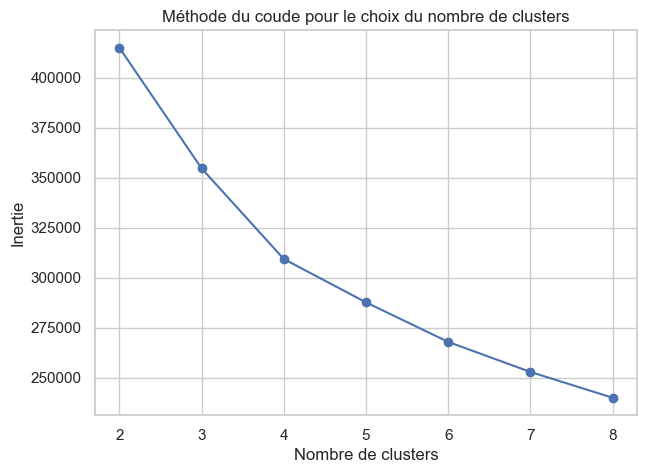

In [61]:
# Méthode du coude pour choisir le nombre de clusters
inertias = []
k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(k_values, inertias, marker="o")
plt.title("Méthode du coude pour le choix du nombre de clusters")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.show()

### Interprétation de la méthode du coude

La méthode du coude montre que l’inertie diminue fortement lorsque le nombre de clusters passe de 2 à 4.  
Après 4 clusters, la baisse continue mais devient plus progressive.

Le choix de **4 clusters** apparaît donc comme un compromis pertinent entre qualité du regroupement et interprétabilité des profils.

Ce choix permet d’identifier plusieurs profils étudiants distincts, tout en conservant une lecture claire des résultats.

## 53. Application du K-means avec 4 clusters

À partir de la méthode du coude, le nombre de clusters retenu est fixé à 4.

Le modèle K-means est ensuite appliqué afin d’attribuer chaque étudiant de l’échantillon à un profil.

In [62]:
# Application du K-means avec 4 clusters
kmeans_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_cluster["cluster"] = kmeans_final.fit_predict(X_cluster_scaled)

# Répartition des clusters
cluster_counts = df_cluster["cluster"].value_counts().sort_index()
cluster_percentages = df_cluster["cluster"].value_counts(normalize=True).sort_index() * 100

print("Répartition brute des clusters :")
print(cluster_counts)

print("\nRépartition en pourcentage :")
print(cluster_percentages.round(2))

Répartition brute des clusters :
cluster
0    28358
1    26389
2    20436
3    24817
Name: count, dtype: int64

Répartition en pourcentage :
cluster
0    28.36
1    26.39
2    20.44
3    24.82
Name: proportion, dtype: float64


### Interprétation de la répartition des clusters

Le K-means avec 4 clusters produit des groupes de tailles relativement équilibrées.

Le cluster 0 représente **28,36 %** de l’échantillon, le cluster 1 **26,39 %**, le cluster 2 **20,44 %** et le cluster 3 **24,82 %**.

Aucun cluster n’est extrêmement minoritaire ou dominant, ce qui facilite l’interprétation des profils.  
Cette répartition suggère que l’algorithme identifie plusieurs groupes d’étudiants distincts, sans isoler uniquement quelques cas atypiques.

L’étape suivante consiste à analyser les caractéristiques moyennes de chaque cluster afin de leur donner une interprétation.

## 54. Profil moyen des clusters

Afin d’interpréter les groupes obtenus, les moyennes des variables utilisées pour le clustering sont calculées pour chaque cluster.

Cette étape permet d’identifier les caractéristiques dominantes de chaque profil étudiant.

In [63]:
# Moyennes des variables par cluster
cluster_profiles = df_cluster.groupby("cluster")[cluster_features].mean()

cluster_profiles

,psychological_distress_index,academic_pressure_index,sleep_deficit,support_protection_index,behavioral_risk_index,vulnerability_score
cluster,,,,,,
0,3.357688,6.557205,0.922545,5.153392,3.314746,0.461391
1,1.661325,4.779422,0.621127,5.570679,3.422594,0.311061
2,4.243730,6.562234,2.932028,3.980003,4.485056,0.607458
3,2.371160,4.862979,2.418163,4.383640,4.566737,0.446498


### Interprétation des profils moyens des clusters

L’analyse des moyennes par cluster permet d’identifier quatre profils étudiants distincts.

Le **cluster 0** présente une pression académique élevée (`academic_pressure_index = 6.56`) et une détresse psychologique modérée à élevée (`psychological_distress_index = 3.36`), mais avec un bon niveau de protection (`support_protection_index = 5.15`) et un déficit de sommeil limité.  
Ce profil peut être interprété comme un groupe d’étudiants sous pression académique, mais disposant encore de facteurs protecteurs.

Le **cluster 1** correspond au profil le plus favorable.  
Il présente la détresse psychologique la plus faible (`1.66`), une pression académique plus basse (`4.78`), un déficit de sommeil faible (`0.62`) et le meilleur score de protection (`5.57`).  
Son score de vulnérabilité est également le plus bas (`0.31`).  
Ce cluster peut donc être interprété comme un profil à faible vulnérabilité.

Le **cluster 2** apparaît comme le profil le plus vulnérable.  
Il présente la détresse psychologique la plus élevée (`4.24`), une pression académique forte (`6.56`), le déficit de sommeil le plus important (`2.93`) et le score de protection le plus faible (`3.98`).  
Son score de vulnérabilité est le plus élevé (`0.61`).  
Ce groupe correspond donc aux étudiants cumulant plusieurs facteurs de risque.

Le **cluster 3** présente une détresse psychologique modérée (`2.37`) et une pression académique plutôt faible (`4.86`), mais un déficit de sommeil élevé (`2.42`) et un risque comportemental important (`4.57`).  
Ce profil semble moins marqué par la pression académique, mais davantage par des facteurs de mode de vie défavorables, notamment le sommeil et les comportements numériques.

Dans l’ensemble, le clustering met en évidence quatre profils interprétables : un profil faiblement vulnérable, un profil sous pression académique, un profil fortement vulnérable et un profil marqué par des difficultés comportementales et de sommeil.

### Interprétation des profils moyens des clusters

L’analyse des moyennes par cluster permet d’identifier quatre profils étudiants distincts.

Le **cluster 0** présente une pression académique élevée (`academic_pressure_index = 6.56`) et une détresse psychologique modérée à élevée (`psychological_distress_index = 3.36`), mais avec un bon niveau de protection (`support_protection_index = 5.15`) et un déficit de sommeil limité.  
Ce profil peut être interprété comme un groupe d’étudiants sous pression académique, mais disposant encore de facteurs protecteurs.

Le **cluster 1** correspond au profil le plus favorable.  
Il présente la détresse psychologique la plus faible (`1.66`), une pression académique plus basse (`4.78`), un déficit de sommeil faible (`0.62`) et le meilleur score de protection (`5.57`).  
Son score de vulnérabilité est également le plus bas (`0.31`).  
Ce cluster peut donc être interprété comme un profil à faible vulnérabilité.

Le **cluster 2** apparaît comme le profil le plus vulnérable.  
Il présente la détresse psychologique la plus élevée (`4.24`), une pression académique forte (`6.56`), le déficit de sommeil le plus important (`2.93`) et le score de protection le plus faible (`3.98`).  
Son score de vulnérabilité est le plus élevé (`0.61`).  
Ce groupe correspond donc aux étudiants cumulant plusieurs facteurs de risque.

Le **cluster 3** présente une détresse psychologique modérée (`2.37`) et une pression académique plutôt faible (`4.86`), mais un déficit de sommeil élevé (`2.42`) et un risque comportemental important (`4.57`).  
Ce profil semble moins marqué par la pression académique, mais davantage par des facteurs de mode de vie défavorables, notamment le sommeil et les comportements numériques.

Dans l’ensemble, le clustering met en évidence quatre profils interprétables : un profil faiblement vulnérable, un profil sous pression académique, un profil fortement vulnérable et un profil marqué par des difficultés comportementales et de sommeil.

## 55. Visualisation des profils de clusters

Une heatmap est utilisée pour visualiser plus clairement les différences entre les clusters.

Les valeurs sont standardisées afin de comparer les profils relativement à la moyenne globale de l’échantillon.

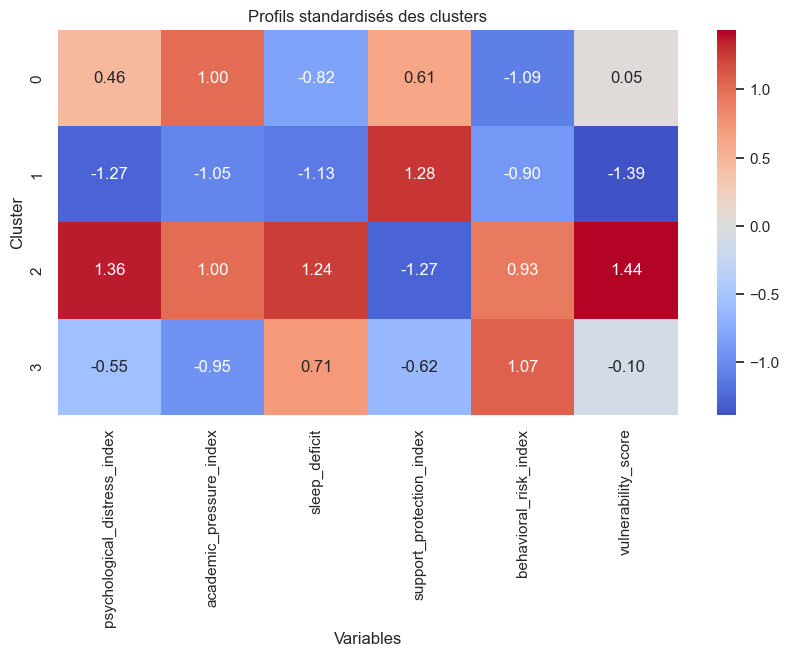

In [64]:
# Standardisation des profils pour une meilleure comparaison visuelle
cluster_profiles_scaled = pd.DataFrame(
    StandardScaler().fit_transform(cluster_profiles),
    index=cluster_profiles.index,
    columns=cluster_profiles.columns
)

plt.figure(figsize=(10, 5))
sns.heatmap(
    cluster_profiles_scaled,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Profils standardisés des clusters")
plt.xlabel("Variables")
plt.ylabel("Cluster")
plt.show()

### Interprétation de la heatmap des clusters

La heatmap confirme les différences entre les quatre profils identifiés par le K-means.

Le **cluster 0** est surtout caractérisé par une pression académique élevée et un niveau de protection supérieur à la moyenne.  
Son déficit de sommeil et son risque comportemental sont inférieurs à la moyenne. Ce profil correspond donc à des étudiants sous pression académique, mais encore relativement protégés.

Le **cluster 1** est le profil le moins vulnérable.  
Il présente des niveaux faibles de détresse psychologique, de pression académique, de déficit de sommeil et de risque comportemental.  
Son niveau de protection est le plus élevé. Ce groupe représente donc les étudiants les plus favorisés du point de vue du risque de burnout.

Le **cluster 2** est le profil le plus préoccupant.  
Il présente une détresse psychologique élevée, une pression académique forte, un déficit de sommeil important, un risque comportemental supérieur à la moyenne et un faible niveau de protection.  
C’est aussi le cluster avec le score de vulnérabilité le plus élevé. Il correspond donc au groupe cumulant le plus de facteurs de risque.

Le **cluster 3** présente un profil différent : la détresse psychologique et la pression académique sont plutôt faibles, mais le déficit de sommeil et le risque comportemental sont élevés.  
Ce groupe semble donc davantage marqué par des habitudes de vie défavorables que par une pression académique ou psychologique forte.

Cette analyse non supervisée complète les modèles prédictifs.  
Elle permet de montrer que le risque de burnout ne correspond pas à un seul profil, mais à plusieurs combinaisons de facteurs.

## 56. Relation entre les clusters et le niveau de risque

Après avoir identifié les profils étudiants par clustering, il est utile de comparer ces clusters avec la variable `risk_level`.

Cette comparaison n’a pas été utilisée pour construire les clusters.  
Elle sert uniquement à interpréter les groupes obtenus et à vérifier si certains profils concentrent davantage d’étudiants à risque élevé.

In [65]:
# Tableau croisé entre cluster et risk_level

cluster_risk_counts = pd.crosstab(df_cluster["cluster"], df_cluster["risk_level"])

cluster_risk_pct = pd.crosstab(

    df_cluster["cluster"],

    df_cluster["risk_level"],

    normalize="index"

) * 100

print("Répartition brute risk_level par cluster :")

display(cluster_risk_counts)

print("Répartition en pourcentage risk_level par cluster :")

display(cluster_risk_pct.round(2))

Répartition brute risk_level par cluster :


risk_level,High,Low,Medium
cluster,,,
0,96,21507,6755
1,0,26246,143
2,1396,6449,12591
3,3,22452,2362


Répartition en pourcentage risk_level par cluster :


risk_level,High,Low,Medium
cluster,,,
0,0.34,75.84,23.82
1,0.00,99.46,0.54
2,6.83,31.56,61.61
3,0.01,90.47,9.52


### Interprétation du lien entre clusters et niveau de risque

La comparaison entre les clusters et la variable `risk_level` permet de vérifier si les profils identifiés par clustering correspondent à des niveaux de risque différents.

Le **cluster 1** correspond au profil le plus favorable.  
Il contient **99,46 %** d’étudiants `Low` et aucun étudiant `High`.  
Ce résultat est cohérent avec son profil moyen : faible détresse psychologique, faible pression académique, faible déficit de sommeil et score de vulnérabilité bas.

Le **cluster 3** est également majoritairement composé d’étudiants `Low`, avec **90,47 %** de `Low` et seulement **0,01 %** de `High`.  
Ce groupe présente surtout des difficultés liées au sommeil et au risque comportemental, mais sans forte détresse psychologique ni forte pression académique.

Le **cluster 0** contient principalement des étudiants `Low` (**75,84 %**) et une proportion non négligeable de `Medium` (**23,82 %**).  
Il ne contient que **0,34 %** de `High`.  
Ce profil semble correspondre à des étudiants soumis à une pression académique élevée, mais encore protégés par un bon niveau de soutien, de sommeil ou d’activité physique.

Le **cluster 2** est le plus préoccupant.  
Il contient **61,61 %** d’étudiants `Medium` et **6,83 %** d’étudiants `High`.  
Cette proportion de `High` est nettement supérieure à la proportion globale du dataset, qui est d’environ **1,51 %**.  
Ce cluster concentre donc davantage de profils à risque élevé.

Ce résultat confirme l’intérêt de l’analyse non supervisée.  
Sans utiliser directement la variable `risk_level`, le clustering permet d’identifier un groupe d’étudiants cumulant plusieurs facteurs de vulnérabilité : détresse psychologique élevée, pression académique forte, déficit de sommeil important, faible protection et score de vulnérabilité élevé.

Le cluster 2 peut donc être interprété comme un profil prioritaire dans une logique de prévention du burnout étudiant.

## 57. Visualisation du niveau de risque par cluster

Une visualisation en pourcentage permet de comparer plus facilement la composition des clusters selon le niveau de risque.

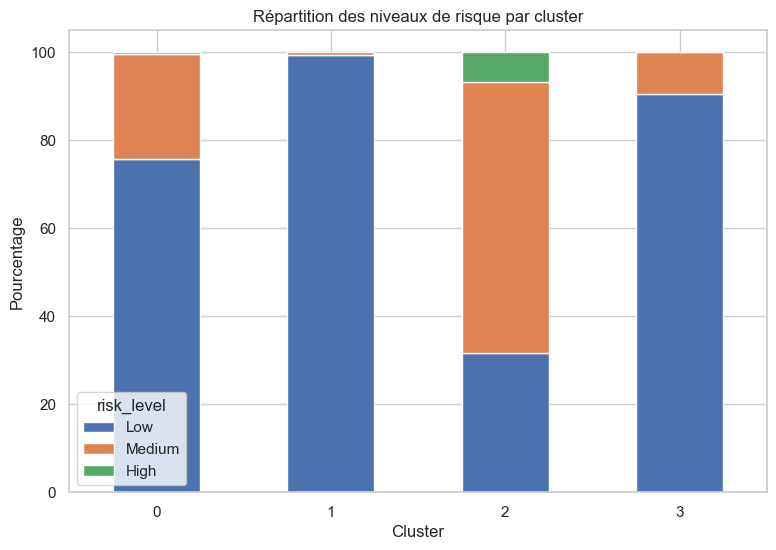

In [66]:
# Visualisation de la répartition des niveaux de risque par cluster

cluster_risk_pct_plot = cluster_risk_pct[["Low", "Medium", "High"]]

cluster_risk_pct_plot.plot(

    kind="bar",

    stacked=True,

    figsize=(9, 6)

)

plt.title("Répartition des niveaux de risque par cluster")

plt.xlabel("Cluster")

plt.ylabel("Pourcentage")

plt.legend(title="risk_level")

plt.xticks(rotation=0)

plt.show()

### Interprétation de la répartition des niveaux de risque par cluster

Le graphique confirme que les clusters présentent des compositions très différentes en termes de niveau de risque.

Le **cluster 1** est presque entièrement composé d’étudiants `Low`.  
Il correspond donc au profil le moins vulnérable.

Le **cluster 3** contient également une très forte majorité d’étudiants `Low`, avec une petite proportion d’étudiants `Medium`.  
Ce profil semble moins critique, même s’il présente certaines difficultés liées au sommeil et aux comportements numériques.

Le **cluster 0** est composé majoritairement d’étudiants `Low`, mais avec une proportion plus importante d’étudiants `Medium`.  
Il peut correspondre à un profil sous pression académique, mais encore protégé.

Le **cluster 2** se distingue clairement des autres.  
Il contient une majorité d’étudiants `Medium` et la plus forte proportion d’étudiants `High`.  
Ce cluster regroupe donc les profils les plus vulnérables, ce qui confirme les résultats obtenus avec les moyennes des variables.

Cette visualisation montre que le clustering apporte une information utile : il permet d’identifier un groupe prioritaire sans utiliser directement la variable `risk_level` lors de la construction des clusters.

## 58. Synthèse de l’analyse non supervisée

L’analyse non supervisée par K-means a permis d’identifier quatre profils étudiants distincts à partir de variables synthétiques liées au burnout.

Le **cluster 1** correspond au profil le plus favorable, avec une faible détresse psychologique, une faible pression académique, peu de déficit de sommeil et un score de vulnérabilité bas.

Le **cluster 0** correspond à un profil sous pression académique, mais disposant encore de facteurs protecteurs.

Le **cluster 3** correspond à un profil marqué par des difficultés de sommeil et un risque comportemental plus élevé, mais sans forte détresse psychologique.

Le **cluster 2** est le profil le plus préoccupant.  
Il cumule une détresse psychologique élevée, une forte pression académique, un déficit de sommeil important, un faible niveau de protection et le score de vulnérabilité le plus élevé.  
Il concentre aussi la plus forte proportion d’étudiants `High`.

Cette analyse complète les modèles supervisés : elle montre que le burnout ne correspond pas à un seul facteur isolé, mais à plusieurs combinaisons de facteurs psychologiques, académiques, comportementaux et sociaux.

## 59. Synthèse générale du projet

Ce projet avait pour objectif d’analyser le burnout étudiant à partir d’un dataset synthétique contenant des variables démographiques, académiques, psychologiques, comportementales et sociales.

L’analyse exploratoire a d’abord montré que le burnout est principalement associé aux variables de détresse psychologique, notamment le stress, l’anxiété et la dépression.  
D’autres facteurs jouent également un rôle important, comme la pression académique, le déficit de sommeil, le soutien social et le stress financier.

La partie régression a permis de prédire le score quantitatif de burnout (`burnout_score`).  
La régression linéaire a constitué une baseline solide, avec un $R^2$ proche de **0.71**.  
Le Random Forest optimisé a obtenu les meilleures performances, avec un $R^2 = 0.7375$, un RMSE de **0.8522** et un MAE de **0.6460**.  
Cela montre que les relations entre les variables et le burnout ne sont pas uniquement linéaires.

La partie classification avait pour objectif de prédire le niveau de risque (`risk_level`).  
La baseline naïve a montré que l’accuracy seule est trompeuse dans un contexte déséquilibré.  
Les modèles pondérés ont permis de mieux détecter la classe `High`, fortement minoritaire.  
La régression logistique pondérée maximise le rappel de la classe `High`, tandis que le Random Forest pondéré offre un meilleur compromis global entre précision, rappel et F1-score macro.

Une contribution méthodologique a ensuite été proposée avec la construction d’un score explicatif de vulnérabilité.  
Ce score combine la détresse psychologique, la pression académique, le déficit de sommeil et les facteurs protecteurs.  
Il est fortement corrélé au score de burnout ($r = 0.7708$) et permet de concentrer les profils à haut risque : dans le top 5 % des scores de vulnérabilité, les étudiants `High` représentent **21,59 %**, contre **1,51 %** dans l’ensemble du dataset.

Une approche de prédiction ensembliste orientée risque élevé a également été testée.  
Elle permet de signaler certains profils ambigus entre `Medium` et `High`.  
Les résultats montrent que cette approche est intéressante conceptuellement, mais que le score de vulnérabilité seul reste plus efficace pour prioriser les profils réellement à haut risque.

Enfin, l’analyse non supervisée par clustering a identifié quatre profils étudiants.  
Le cluster le plus préoccupant cumule une forte détresse psychologique, une forte pression académique, un déficit de sommeil important, un faible niveau de protection et la plus forte proportion d’étudiants `High`.

Dans l’ensemble, le projet montre que le burnout étudiant est associé à une combinaison de facteurs psychologiques, académiques, comportementaux et sociaux.  
L’approche la plus pertinente n’est donc pas seulement prédictive, mais aussi explicative et orientée vers la priorisation des profils vulnérables.

## 60. Limites du projet

Plusieurs limites doivent être prises en compte dans l’interprétation des résultats.

La première limite concerne la nature du dataset.  
Le jeu de données est synthétique : il ne correspond pas à des observations réelles d’étudiants.  
Les résultats obtenus permettent donc d’étudier des relations statistiques plausibles et de tester des méthodes de data science, mais ils ne doivent pas être interprétés comme des conclusions cliniques ou diagnostiques.

Une deuxième limite concerne le déséquilibre de la variable `risk_level`.  
La classe `High` représente seulement **1,51 %** des observations.  
Même si elle contient plus de 15 000 exemples en valeur absolue, elle reste très minoritaire par rapport aux classes `Low` et `Medium`.  
Cela rend l’évaluation plus complexe et justifie l’utilisation de métriques comme le F1-score macro et le rappel de la classe `High`.

Une troisième limite concerne les variables dérivées.  
Certaines variables du dataset, comme `burnout_score`, `mental_health_index`, `risk_level` et `dropout_risk`, sont fortement liées entre elles.  
Pour éviter une fuite d’information, plusieurs variables ont été exclues selon la tâche de modélisation.  
Cependant, cette proximité entre indicateurs doit être gardée à l’esprit lors de l’interprétation.

Une quatrième limite concerne la causalité.  
Les analyses réalisées montrent des associations statistiques entre les variables, mais elles ne permettent pas d’établir des relations causales.  
Par exemple, un niveau élevé de stress est associé à un score de burnout plus élevé, mais le projet ne permet pas d’affirmer que le stress cause directement le burnout.

Une cinquième limite concerne l’absence de dimension temporelle.  
Le burnout est un phénomène progressif, qui peut évoluer dans le temps.  
Or, le dataset utilisé est statique : il ne permet pas de suivre l’évolution individuelle des étudiants ni d’analyser des trajectoires de risque.

Enfin, la contribution proposée repose sur des seuils, notamment pour le top 5 % du score de vulnérabilité et pour les règles de prédiction ensembliste.  
Ces seuils sont pertinents pour l’analyse, mais ils restent discutables et pourraient être ajustés selon le contexte d’utilisation.

## 61. Perspectives d’amélioration

Plusieurs pistes peuvent être envisagées pour améliorer ou prolonger ce projet.

Une première perspective serait de tester les modèles sur des données réelles.  
Cela permettrait de vérifier si les relations observées dans le dataset synthétique se retrouvent dans un contexte réel, avec des étudiants effectivement interrogés.

Une deuxième perspective serait d’intégrer une dimension temporelle.  
Le burnout évolue progressivement, il serait donc intéressant de disposer de données longitudinales afin d’étudier les trajectoires de risque et non seulement un état observé à un instant donné.

Une troisième perspective serait d’améliorer l’explicabilité des modèles.  
L’utilisation de méthodes comme SHAP permettrait d’analyser plus finement l’influence des variables sur les prédictions individuelles, notamment pour les étudiants prédits à haut risque.

Une quatrième perspective serait d’approfondir le score de vulnérabilité.  
Dans ce projet, le score repose sur une combinaison simple et interprétable de variables.  
Il pourrait être amélioré en pondérant les dimensions selon leur importance statistique ou selon des connaissances issues de la littérature.

Une cinquième perspective serait d’améliorer la prédiction ensembliste.  
Les règles testées ont montré un intérêt conceptuel, mais elles restent limitées dans leur capacité à capturer les profils `High`.  
Des seuils plus adaptés ou une méthode de calibration des probabilités pourraient améliorer cette approche.

Enfin, une dernière perspective serait de construire un outil de visualisation ou un tableau de bord.  
Un tel outil permettrait de suivre les profils de vulnérabilité, d’identifier les groupes à risque et de rendre les résultats plus exploitables dans une logique de prévention.

## 62. Conclusion finale

Ce projet a permis d’étudier le burnout étudiant à partir d’une démarche complète de data science, combinant analyse exploratoire, modélisation prédictive, explicabilité et clustering.

Les résultats montrent que le burnout est principalement associé à la détresse psychologique, représentée par le stress, l’anxiété et la dépression.  
La pression académique, le déficit de sommeil et le soutien social jouent également un rôle important.

Sur la tâche de régression, le Random Forest optimisé obtient les meilleures performances pour prédire le score de burnout.  
Sur la tâche de classification, les modèles pondérés permettent de mieux prendre en compte le déséquilibre des classes et d’améliorer la détection des étudiants à risque élevé.

La principale contribution du projet repose sur la construction d’un score explicatif de vulnérabilité.  
Ce score permet de prioriser les profils les plus exposés au risque de burnout, tout en conservant une interprétation claire des facteurs associés.  
Il ne remplace pas les modèles classiques, mais il apporte une lecture complémentaire plus adaptée à une logique de prévention.

L’approche de prédiction ensembliste a également été testée afin de signaler certains profils ambigus entre `Medium` et `High`.  
Les résultats montrent que cette méthode est intéressante conceptuellement, mais qu’elle nécessite encore des améliorations pour être pleinement efficace.

Enfin, le clustering a permis d’identifier plusieurs profils étudiants distincts, dont un profil particulièrement vulnérable cumulant détresse psychologique, pression académique, déficit de sommeil et faible niveau de protection.

En conclusion, ce projet montre que la prédiction du burnout étudiant ne doit pas être abordée uniquement comme un problème de performance algorithmique.  
L’enjeu principal est aussi d’identifier, d’expliquer et de prioriser les profils vulnérables, afin de proposer une analyse utile dans une perspective de prévention.